In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO

# Load your HTML file
with open('../../../Sensitive Coding/blizzard/blizzard_data.html', 'r', encoding='utf-8') as f:
    html = f.read()

# Parse with BeautifulSoup
soup = BeautifulSoup(html, 'html.parser')

# Process headers and tables
tables_with_headers = []
elements = soup.find_all(['h2', 'table'])

current_header = None

for el in elements:
    if el.name == 'h2':
        current_header = el.get_text(strip=True)
    elif el.name == 'table':
        # Wrap HTML string in StringIO to avoid the FutureWarning
        table_html = str(el)
        df = pd.read_html(StringIO(table_html))[0]
        tables_with_headers.append((current_header, df))

In [3]:
#Hiding output so sensitive information not shown

# # Display result
# for idx, (header, df) in enumerate(tables_with_headers):
#     if "Player" or "Hero" in header:
#         print(f"\n--- Table {idx+1} ---")
#         print(f"Header: {header}")
#         print(df.head())

* Looking at the HTML file, the only tables we want for now are 47, 48, and 50

## Maps

In [4]:
maps = tables_with_headers[47]
maps

('Player Map Stat',
      Stat Context Type                 Stat Context Name               Map  \
 0             UNRANKED                               NaN  Temple of Anubis   
 1             UNRANKED                               NaN  Temple of Anubis   
 2             UNRANKED                               NaN  Temple of Anubis   
 3             UNRANKED                               NaN  Temple of Anubis   
 4             UNRANKED                               NaN        King's Row   
 ...                ...                               ...               ...   
 1629           RULESET  Stadium - OW2 Ranked - Season 02  Throne of Anubis   
 1630           RULESET  Stadium - OW2 Ranked - Season 02           Hanaoka   
 1631           RULESET  Stadium - OW2 Ranked - Season 02           Hanaoka   
 1632           RULESET  Stadium - OW2 Ranked - Season 02          Colosseo   
 1633           RULESET  Stadium - OW2 Ranked - Season 02          Colosseo   
 
                              

In [5]:
maps = pd.DataFrame(maps[1])

In [6]:
maps.head(15)

,Stat Context Type,Stat Context Name,Map,Stat,Amount
0,UNRANKED,NaN,Temple of Anubis,Map Rpl {0}:Win:Wins;,1.0
1,UNRANKED,NaN,Temple of Anubis,Map Rpl {0}:Enter:Enters;,1.0
2,UNRANKED,NaN,Temple of Anubis,Offense Rpl {0}:Win:Wins;,1.0
3,UNRANKED,NaN,Temple of Anubis,Offense Rpl {0}:Enter:Enters;,1.0
4,UNRANKED,NaN,King's Row,Map Rpl {0}:Win:Wins;,15.0
5,UNRANKED,NaN,King's Row,Map Rpl {0}:Enter:Enters;,28.0
6,UNRANKED,NaN,King's Row,Offense Rpl {0}:Win:Wins;,10.0
7,UNRANKED,NaN,King's Row,Offense Rpl {0}:Enter:Enters;,14.0
8,UNRANKED,NaN,King's Row,Defense Rpl {0}:Win:Wins;,5.0
9,UNRANKED,NaN,King's Row,Defense Rpl {0}:Enter:Enters;,14.0


In [7]:
# Sample: filter categorical columns (object or category)
categorical_cols = maps.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    unique_vals = maps[col].unique()
    print(f"\nColumn: {col}")
    print(unique_vals)


Column: Stat Context Type
['UNRANKED' 'VS_AI' 'RULESET']

Column: Stat Context Name
[nan 'Elimination' 'Mystery Heroes' 'Team Deathmatch' 'Deathmatch'
 'Halloween' 'No Limits' 'LucioBaller' 'OW2 Ranked - Season 01'
 'OW2 Ranked - Season 01 OpenQueue' 'Quick Play Open Queue' 'Junkenstein2'
 'OW2 Ranked - Season 02 OpenQueue' 'OW2 Ranked - Season 02'
 'OW2 Ranked - Season 03' 'OW2 Ranked - Season 03 OpenQueue'
 'OlympusDeathmatch' 'OW2 Ranked - Season 04'
 'OW2 Ranked - Season 04 OpenQueue' 'Hero Mastery - Easy'
 'OW2 Ranked - Season 05' 'GreaterRift' 'VolleyBall'
 'Hero Mastery - Medium' 'Prop Hunt' 'OW2 Ranked - Season 06'
 'OW2 Ranked - Season 07' 'Event Mission - London Fog'
 'OW2 Ranked - Season 08' 'OW2 Ranked - Season 09'
 'Extraction - Antarctica' 'OW2 Ranked - Season 10'
 'OW2 Ranked - Season 11' 'OW2 Ranked - Season 11 OpenQueue'
 'OW2 Ranked - Season 12' 'OW2 Ranked - Season 13'
 'OW2 Ranked - Season 13 OpenQueue' 'Stadium - OW2 Ranked - Season 01'
 'OW2 Ranked - Season 14' '

In [8]:
#Filtering to records where Stat Context Name only has ranked values in it
maps = maps[maps['Stat Context Name'].str.contains('OW2 Ranked', case=False, na=False)]
maps = maps[~maps['Stat Context Name'].str.contains('Stadium|Open', case=False, na=False)]

In [9]:
maps.drop('Stat Context Type', axis=1, inplace=True)

In [10]:
# Step 1: Extract the stat type (e.g., Enter, Win, Tie) from the Stat column
maps['Stat_Type'] = maps['Stat'].str.extract(r':(\w+):')

# Step 2: Pivot the table using pivot
maps_wide = maps.pivot_table(
    index=['Stat Context Name', 'Map'],
    columns='Stat_Type',
    values='Amount',
    aggfunc='sum'  # In case multiple rows exist for the same stat
).reset_index()

In [11]:
maps_wide.fillna(0, inplace=True)
maps = maps_wide.copy(deep=True)

In [12]:
maps.head()

Stat_Type,Stat Context Name,Map,Enter,Tie,Win
0,OW2 Ranked - Season 01,Busan,1.0,0.0,0.0
1,OW2 Ranked - Season 01,Circuit royal,1.0,0.0,1.0
2,OW2 Ranked - Season 01,Dorado,1.0,0.0,0.0
3,OW2 Ranked - Season 01,Nepal,1.0,0.0,1.0
4,OW2 Ranked - Season 01,Paraíso,1.0,0.0,0.0


In [13]:
maps['Loss'] = (maps['Enter'] - (maps['Tie'] + maps['Win']))
maps.head()

Stat_Type,Stat Context Name,Map,Enter,Tie,Win,Loss
0,OW2 Ranked - Season 01,Busan,1.0,0.0,0.0,1.0
1,OW2 Ranked - Season 01,Circuit royal,1.0,0.0,1.0,0.0
2,OW2 Ranked - Season 01,Dorado,1.0,0.0,0.0,1.0
3,OW2 Ranked - Season 01,Nepal,1.0,0.0,1.0,0.0
4,OW2 Ranked - Season 01,Paraíso,1.0,0.0,0.0,1.0


In [14]:
maps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Stat Context Name  427 non-null    object 
 1   Map                427 non-null    object 
 2   Enter              427 non-null    float64
 3   Tie                427 non-null    float64
 4   Win                427 non-null    float64
 5   Loss               427 non-null    float64
dtypes: float64(4), object(2)
memory usage: 20.1+ KB


In [15]:
maps.describe()

Stat_Type,Enter,Tie,Win,Loss
count,427.000000,427.000000,427.000000,427.000000
mean,7.922717,0.274005,3.943794,3.704918
std,4.310281,0.528399,2.574090,2.419997
min,1.000000,0.000000,0.000000,0.000000
25%,4.000000,0.000000,2.000000,2.000000
50%,7.000000,0.000000,4.000000,3.000000
75%,11.000000,0.000000,5.000000,5.000000
max,25.000000,3.000000,12.000000,12.000000


In [16]:
maps.rename(columns={'Tie': 'Draw'}, inplace=True)

#### Win Percentages

In [17]:
# Group by map
summary = maps.groupby('Map').agg(
    Enters=('Enter', 'sum'),
    Draw=('Draw', 'sum'),
    Win=('Win', 'sum'),
    Loss=('Loss', 'sum')
)
summary.reset_index(inplace=True)

agg_list = ['Win','Draw','Loss']

In [18]:
summary

,Map,Enters,Draw,Win,Loss
0,Aatlis,10.0,0.0,5.0,5.0
1,Antarctic Peninsula,92.0,2.0,44.0,46.0
2,Blizzard World,130.0,7.0,62.0,61.0
3,Busan,117.0,3.0,65.0,49.0
4,Circuit royal,129.0,5.0,71.0,53.0
5,Colosseo,152.0,4.0,71.0,77.0
6,Dorado,132.0,1.0,76.0,55.0
7,Eichenwalde,108.0,4.0,52.0,52.0
8,Esperança,163.0,6.0,82.0,75.0
9,Hanaoka,25.0,1.0,14.0,10.0


In [19]:
# Calculate win percentage
for col in agg_list:
    summary[f"{col} %"] = (summary[col] / summary['Enters']) * 100

In [20]:
summary = summary.round(0)
summary = summary.sort_values(by='Win %', ascending=False).reset_index(drop=True)
summary

,Map,Enters,Draw,Win,Loss,Win %,Draw %,Loss %
0,Runasapi,49.0,1.0,33.0,15.0,67.0,2.0,31.0
1,Suravasa,102.0,0.0,60.0,42.0,59.0,0.0,41.0
2,Dorado,132.0,1.0,76.0,55.0,58.0,1.0,42.0
3,Busan,117.0,3.0,65.0,49.0,56.0,3.0,42.0
4,Hanaoka,25.0,1.0,14.0,10.0,56.0,4.0,40.0
5,Circuit royal,129.0,5.0,71.0,53.0,55.0,4.0,41.0
6,Lijiang Tower,117.0,4.0,63.0,50.0,54.0,3.0,43.0
7,Junkertown,124.0,1.0,67.0,56.0,54.0,1.0,45.0
8,Rialto,132.0,6.0,71.0,55.0,54.0,5.0,42.0
9,King's Row,131.0,9.0,70.0,52.0,53.0,7.0,40.0


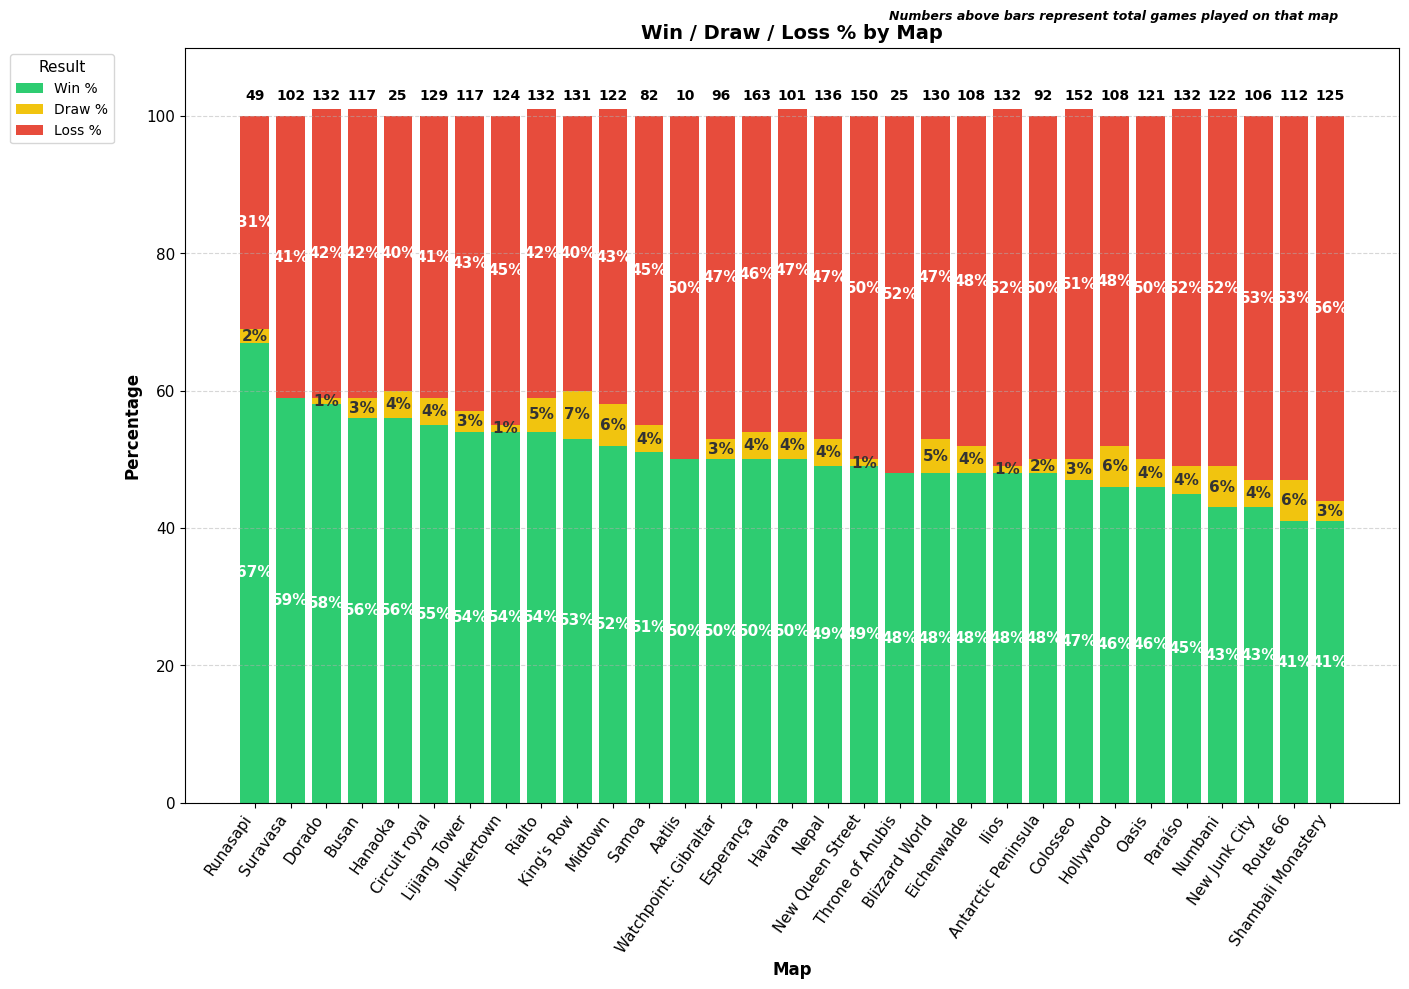

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))

# Colors (use your preferred palette)
win_color = '#2ECC71'
draw_color = '#F1C40F'
loss_color = '#E74C3C'

bottom_draw = summary['Win %']
bottom_loss = summary['Win %'] + summary['Draw %']

# Plot bars
plt.bar(summary['Map'], summary['Win %'], label='Win %', color=win_color)
plt.bar(summary['Map'], summary['Draw %'], bottom=bottom_draw, label='Draw %', color=draw_color)
plt.bar(summary['Map'], summary['Loss %'], bottom=bottom_loss, label='Loss %', color=loss_color)

# Add % labels inside each segment
for i, row in summary.iterrows():
    if row['Win %'] > 0:
        plt.text(i, row['Win %'] / 2, f"{int(row['Win %'])}%", ha='center', va='center', color='white', fontsize=11, weight='bold')
    if row['Draw %'] > 0:
        plt.text(i, bottom_draw[i] + row['Draw %'] / 2, f"{int(row['Draw %'])}%", ha='center', va='center', color='#333', fontsize=11, weight='bold')
    if row['Loss %'] > 0:
        plt.text(i, bottom_loss[i] + row['Loss %'] / 2, f"{int(row['Loss %'])}%", ha='center', va='center', color='white', fontsize=11, weight='bold')

# Add total games played above each bar
# Replace 'Total Games' with your actual total games count column!
for i, total in enumerate(summary['Enters']):
    plt.text(i, 102, int(total), ha='center', va='bottom', fontsize=10, color='black', weight='bold')

ax = plt.gca()
ax.text(0.95, 1.05, "Numbers above bars represent total games played on that map",
        transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic', weight='bold')
    
# Final touches    
plt.xticks(rotation=55, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Map', fontsize=12, weight='bold')
plt.ylabel('Percentage', fontsize=12, weight='bold')
plt.title('Win / Draw / Loss % by Map', fontsize=14, weight='bold')
plt.ylim(0, 110)  # add some space above 100% for total games text
plt.legend(title='Result', title_fontsize=11, fontsize=10, loc='upper left', bbox_to_anchor=(-0.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Raw Win / Draw / Losses

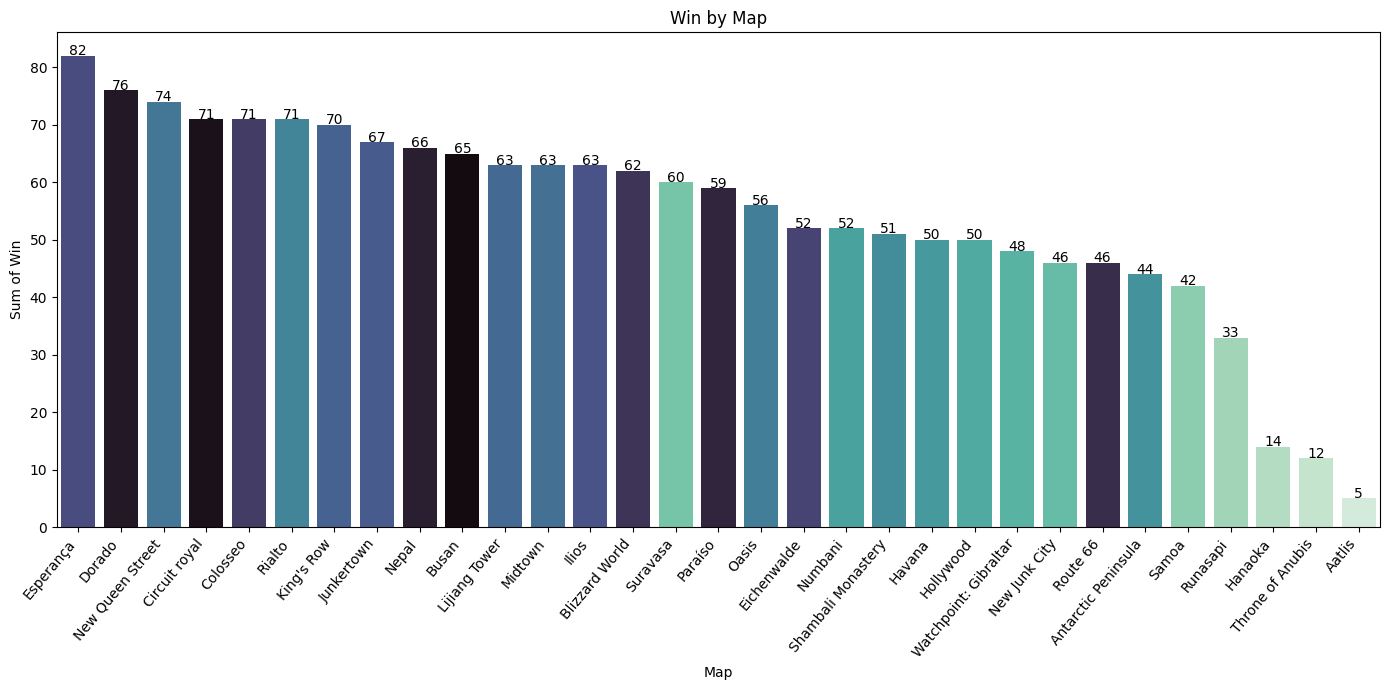

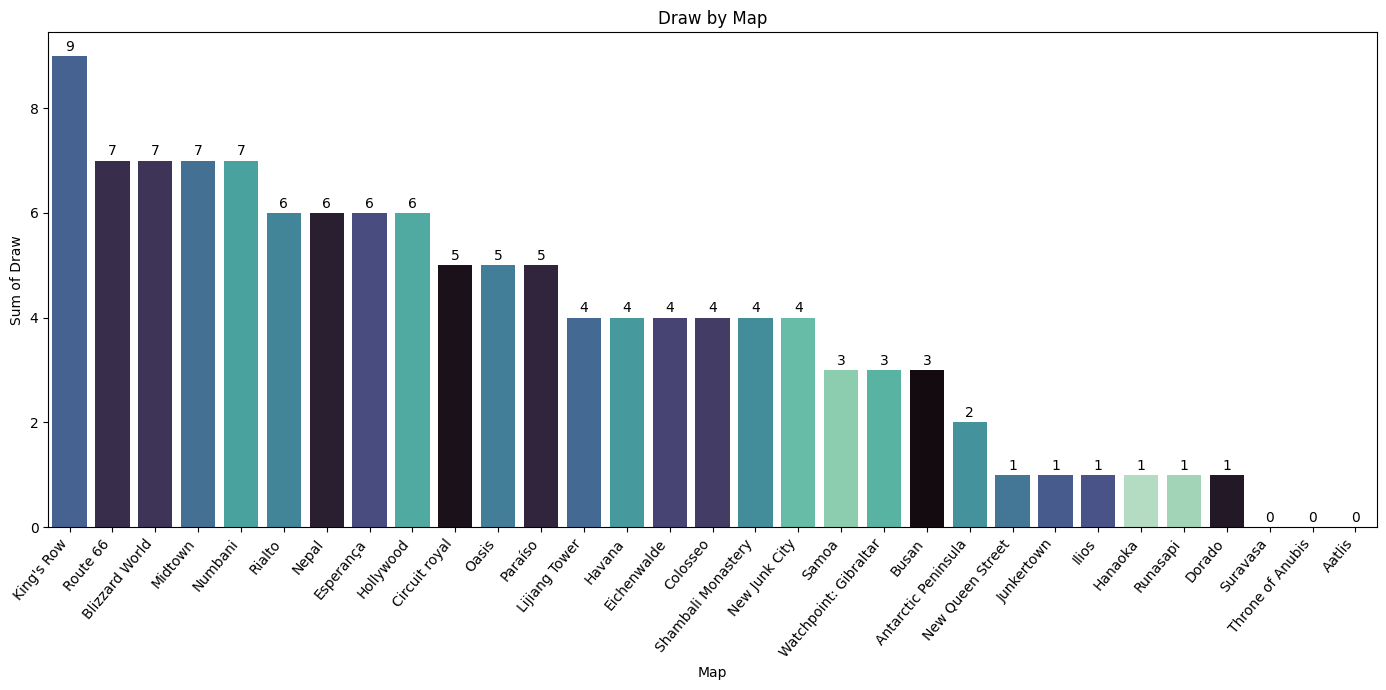

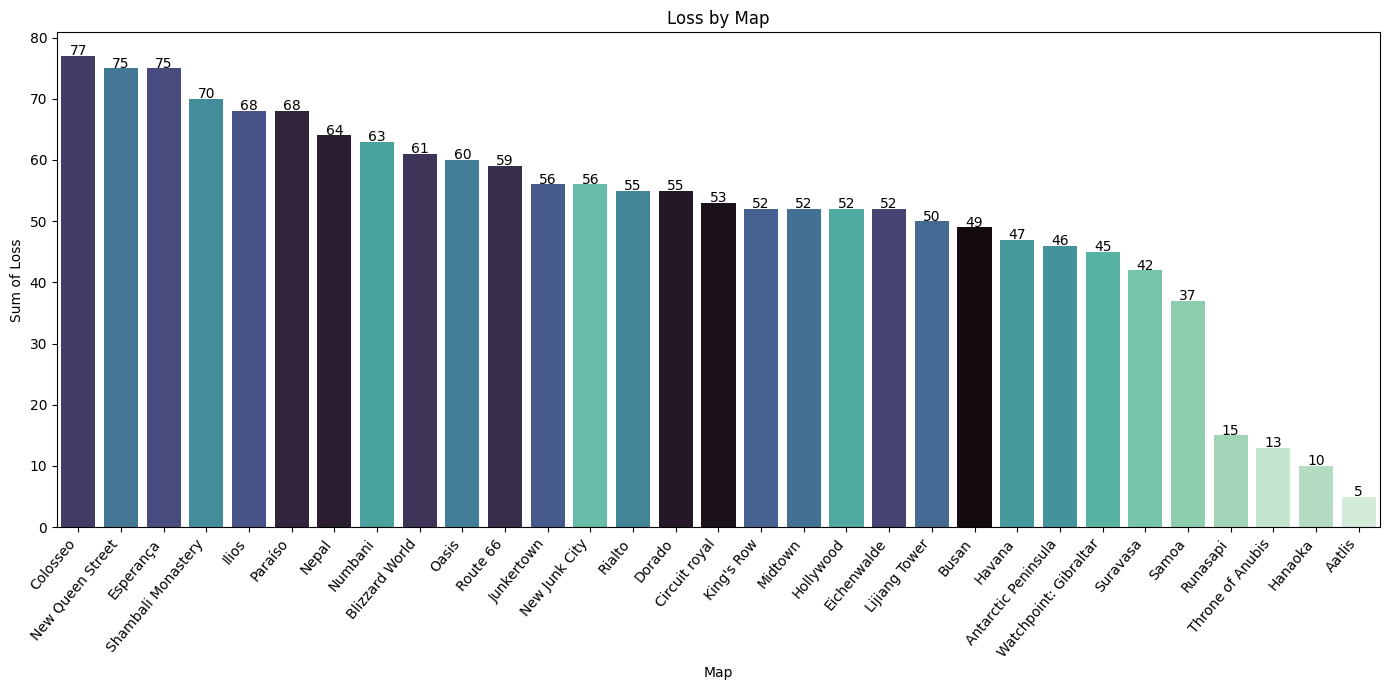

In [22]:
clist = ['Win', 'Draw', 'Loss']

for column in clist:
    
    #Create new figure for each column
    plt.figure(figsize=(14, 7)) 
    
    #Grouping by totals for custom ordering in graphs below
    order = maps.groupby('Map')[column].sum().sort_values(ascending=False).index
    
    ax = sns.barplot(data=maps, x='Map', y=column, hue='Map', palette='mako', estimator=sum, errorbar=None, order=order)

    # Annotate each bar with its height value above the bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,  # X coordinate: center of the bar
            height + 0.1,                    # Y coordinate: a bit above the bar
            f'{height:.0f}',                 # Text to display (formatted as int)
            ha='center'                      # Center alignment horizontally
        )
        
    plt.xticks(rotation=50, ha='right')
    plt.title(f'Total {column} per Map')
    plt.ylabel(f'Sum of {column}')
    plt.title(f'{column} by Map')
    plt.tight_layout()

## Player Seasonal Data

In [23]:
player_all = tables_with_headers[48]

In [24]:
player_all

('Player All Hero Stat',
     Stat Context Type                 Stat Context Name  \
 0            UNRANKED                               NaN   
 1            UNRANKED                               NaN   
 2            UNRANKED                               NaN   
 3            UNRANKED                               NaN   
 4            UNRANKED                               NaN   
 ..                ...                               ...   
 665           RULESET  Stadium - OW2 Ranked - Season 02   
 666           RULESET  Stadium - OW2 Ranked - Season 02   
 667           RULESET  Stadium - OW2 Ranked - Season 02   
 668           RULESET  Stadium - OW2 Ranked - Season 02   
 669           RULESET  Stadium - OW2 Ranked - Season 02   
 
                                                  Stat        Amount  
 0    Rpl {0}:Elimination:Eliminations; - Most in Game     40.000000  
 1            Final Rpl {0}:Blow:Blows; - Most in Game     26.000000  
 2                      All Damage Done 

In [25]:
pall = pd.DataFrame(player_all[1])
pall.head()

,Stat Context Type,Stat Context Name,Stat,Amount
0,UNRANKED,NaN,Rpl {0}:Elimination:Eliminations; - Most in Game,40.000000
1,UNRANKED,NaN,Final Rpl {0}:Blow:Blows; - Most in Game,26.000000
2,UNRANKED,NaN,All Damage Done - Most in Game,39523.953601
3,UNRANKED,NaN,Healing Done - Most in Game,15959.400781
4,UNRANKED,NaN,Defensive Rpl {0}:Assist:Assists; - Most in Game,41.000000


In [26]:
# Sample: filter categorical columns (object or category)
categorical_cols = pall.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    unique_vals = pall[col].unique()
    print(f"\nColumn: {col}")
    print(unique_vals)


Column: Stat Context Type
['UNRANKED' 'VS_AI' 'CONTEXTLESS' 'RULESET']

Column: Stat Context Name
[nan 'Elimination' 'Mystery Heroes' 'Team Deathmatch' 'Deathmatch'
 'No Limits' 'OW2 Ranked - Season 01' 'OW2 Ranked - Season 01 OpenQueue'
 'Quick Play Open Queue' 'OW2 Ranked - Season 02 OpenQueue'
 'OW2 Ranked - Season 02' 'OW2 Ranked - Season 03'
 'OW2 Ranked - Season 03 OpenQueue' 'OlympusDeathmatch'
 'OW2 Ranked - Season 04' 'OW2 Ranked - Season 04 OpenQueue'
 'OW2 Ranked - Season 05' 'Prop Hunt' 'OW2 Ranked - Season 06'
 'OW2 Ranked - Season 07' 'OW2 Ranked - Season 08'
 'OW2 Ranked - Season 09' 'OW2 Ranked - Season 10'
 'OW2 Ranked - Season 11' 'OW2 Ranked - Season 11 OpenQueue'
 'OW2 Ranked - Season 12' 'OW2 Ranked - Season 13'
 'OW2 Ranked - Season 13 OpenQueue' 'Stadium - OW2 Ranked - Season 01'
 'OW2 Ranked - Season 14' 'OW2 Ranked - Season 15'
 'OW2 Ranked - Season 15 OpenQueue' 'OW2 Ranked - Season 16'
 'OW2 Ranked - Season 16 OpenQueue' 'OW2 Ranked - Season 17'
 'Stadium - 

In [27]:
#Filtering to records where Stat Context Name only has ranked values in it
pall = pall[pall['Stat Context Name'].str.contains('OW2 Ranked', case=False, na=False)]
pall = pall[~pall['Stat Context Name'].str.contains('Stadium|Open', case=False, na=False)]

In [28]:
pall.drop("Stat Context Type", axis=1 ,inplace=True)

In [29]:
pall['Stat'].unique()

array(['Rpl {0}:Elimination:Eliminations; - Most in Game',
       'Final Rpl {0}:Blow:Blows; - Most in Game',
       'All Damage Done - Most in Game', 'Healing Done - Most in Game',
       'Defensive Rpl {0}:Assist:Assists; - Most in Game',
       'Offensive Rpl {0}:Assist:Assists; - Most in Game',
       'Objective Rpl {0}:Kill:Kills; - Most in Game',
       'Objective Time - Most in Game', 'Multikill - Best',
       'Solo Rpl {0}:Kill:Kills; - Most in Game',
       'Time Spent on Fire - Most in Game', 'Kill Streak - Best',
       'Hero Damage Done - Most in Game',
       'Barrier Damage Done - Most in Game',
       'Rpl {0}:Assist:Assists; - Most in Game',
       'Objective Contest Time - Most in Game',
       'Melee Final Rpl {0}:Blow:Blows; - Most in Game',
       'Environmental Rpl {0}:Kill:Kills; - Most in Game'], dtype=object)

In [30]:
import re

def extract_stat_type(s):
    # Try complex pattern: extract first word and third word from colon section
    match = re.match(r'(\w+).*?:(\w+):(\w+)', s)
    if match:
        return f"{match.group(1)} {match.group(3)}"

    # If no match, but there is a colon, extract :word:
    colon_match = re.search(r':(\w+):', s)
    if colon_match:
        return colon_match.group(1)

    # If no colons, strip trailing dash phrase if present
    return re.split(r'\s*-\s*', s)[0].strip()
    
pall['Stat_Type'] = pall['Stat'].apply(extract_stat_type)

In [31]:
pall['Stat_Type'] = pall['Stat_Type'].str.replace(r'Rpl|All', '', regex=True).str.strip()

In [32]:
pall['Stat_Type'].unique()

array(['Eliminations', 'Final Blows', 'Damage Done', 'Healing Done',
       'Defensive Assists', 'Offensive Assists', 'Objective Kills',
       'Objective Time', 'Multikill', 'Solo Kills', 'Time Spent on Fire',
       'Kill Streak', 'Hero Damage Done', 'Barrier Damage Done',
       'Assists', 'Objective Contest Time', 'Melee Blows',
       'Environmental Kills'], dtype=object)

In [33]:
pall['Season'] = pall['Stat Context Name'].apply(lambda x: ' '.join(x.split(' ')[3:5]))
pall.drop(["Stat Context Name", "Stat"], axis=1, inplace=True)

In [34]:
#Reordering columns
pall = pall[['Season', 'Stat_Type', 'Amount']]
pall.head()

,Season,Stat_Type,Amount
176,Season 01,Eliminations,24.000000
177,Season 01,Final Blows,15.000000
178,Season 01,Damage Done,10720.392185
179,Season 01,Healing Done,10722.860218
180,Season 01,Defensive Assists,18.000000


In [35]:
pall['Amount'] = pall['Amount'].astype(int)
pall['Stat_Type'] = pall['Stat_Type'].apply(lambda x: x.split(' - ')[0])
pall.head()

,Season,Stat_Type,Amount
176,Season 01,Eliminations,24
177,Season 01,Final Blows,15
178,Season 01,Damage Done,10720
179,Season 01,Healing Done,10722
180,Season 01,Defensive Assists,18


In [36]:
# Pivot the DataFrame
pivoted = pall.pivot(
    index='Season', 
    columns='Stat_Type', 
    values='Amount').reset_index()
pivoted = pivoted.fillna(0)

In [37]:
pivoted.head()

Stat_Type,Season,Assists,Barrier Damage Done,Damage Done,Defensive Assists,Eliminations,Environmental Kills,Final Blows,Healing Done,Hero Damage Done,Kill Streak,Melee Blows,Multikill,Objective Contest Time,Objective Kills,Objective Time,Offensive Assists,Solo Kills,Time Spent on Fire
0,Season 01,17.0,3880.0,10720.0,18.0,24.0,0.0,15.0,10722.0,6840.0,16.0,0.0,4.0,44.0,11.0,196.0,5.0,15.0,64.0
1,Season 02,51.0,11990.0,30873.0,53.0,57.0,3.0,30.0,28900.0,22061.0,21.0,2.0,4.0,296.0,33.0,387.0,23.0,30.0,518.0
2,Season 03,51.0,14456.0,44061.0,57.0,46.0,2.0,25.0,25747.0,24984.0,20.0,2.0,5.0,260.0,26.0,307.0,28.0,25.0,526.0
3,Season 04,45.0,11046.0,42303.0,52.0,44.0,1.0,28.0,26290.0,23847.0,22.0,2.0,4.0,260.0,30.0,362.0,19.0,28.0,426.0
4,Season 05,30.0,8817.0,41404.0,32.0,46.0,2.0,26.0,19923.0,25617.0,22.0,1.0,3.0,316.0,29.0,570.0,15.0,26.0,515.0


In [38]:
clist2 = pivoted.drop(["Season"], axis=1)

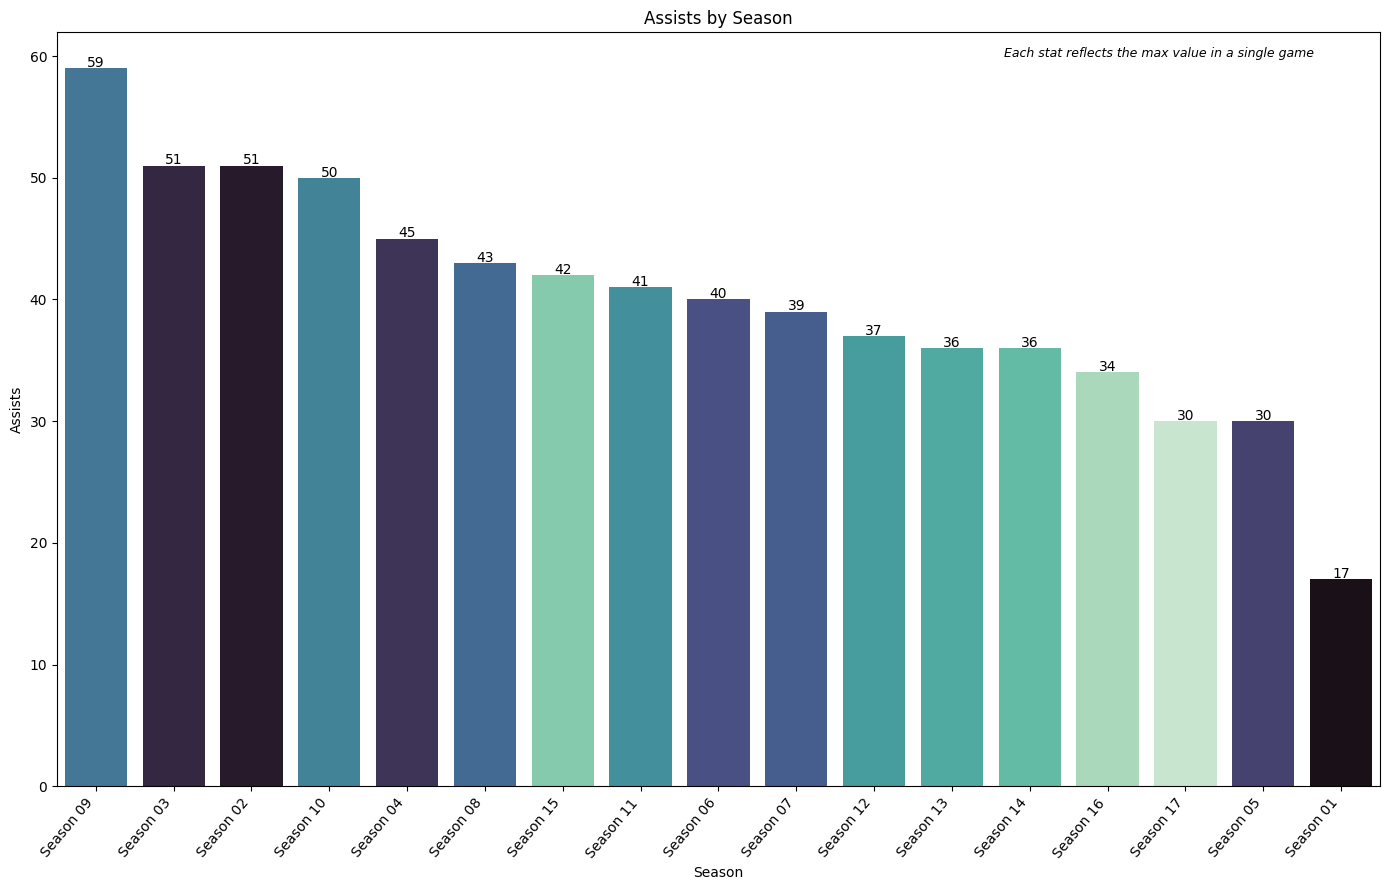

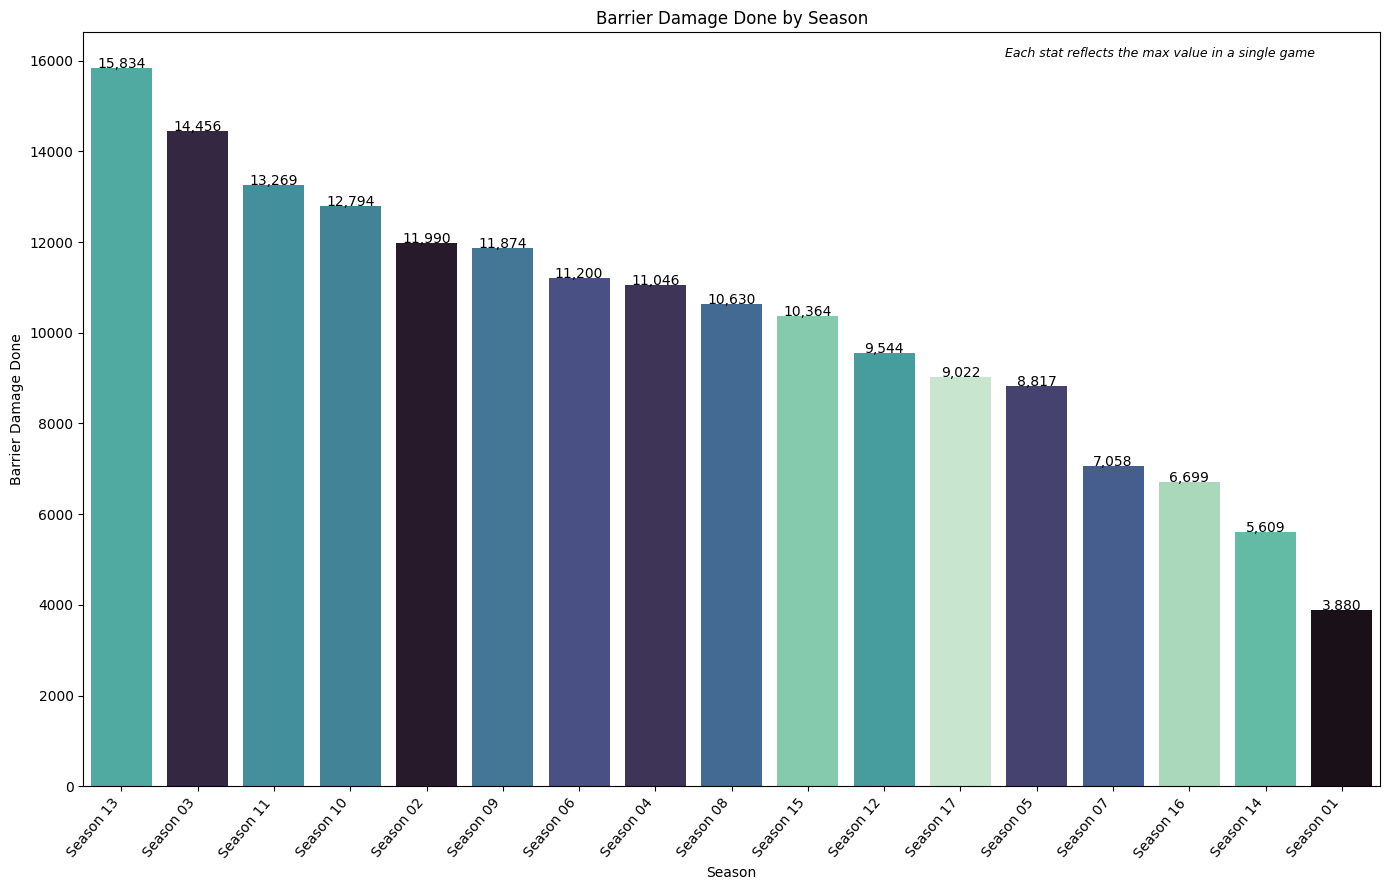

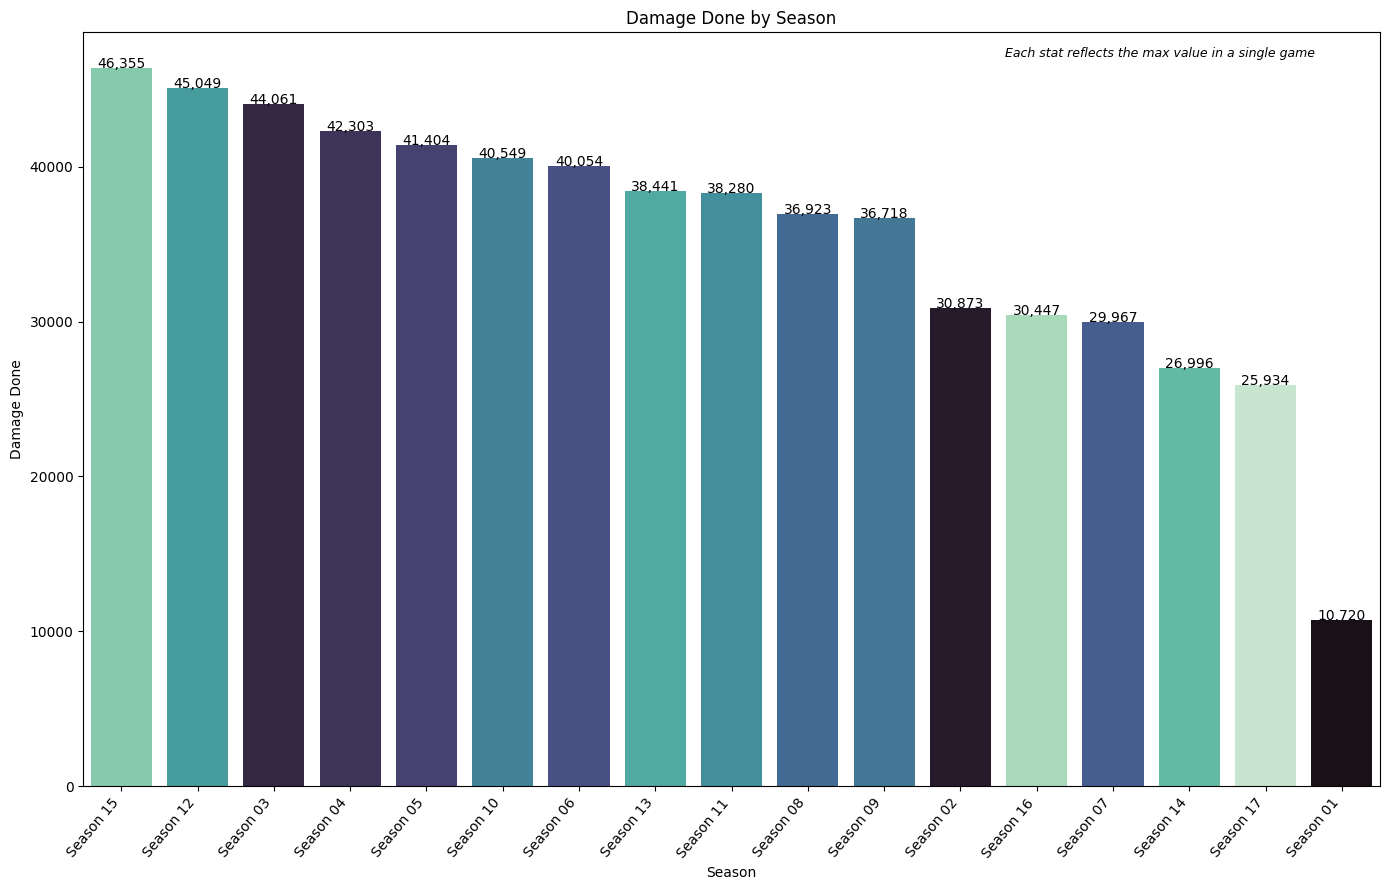

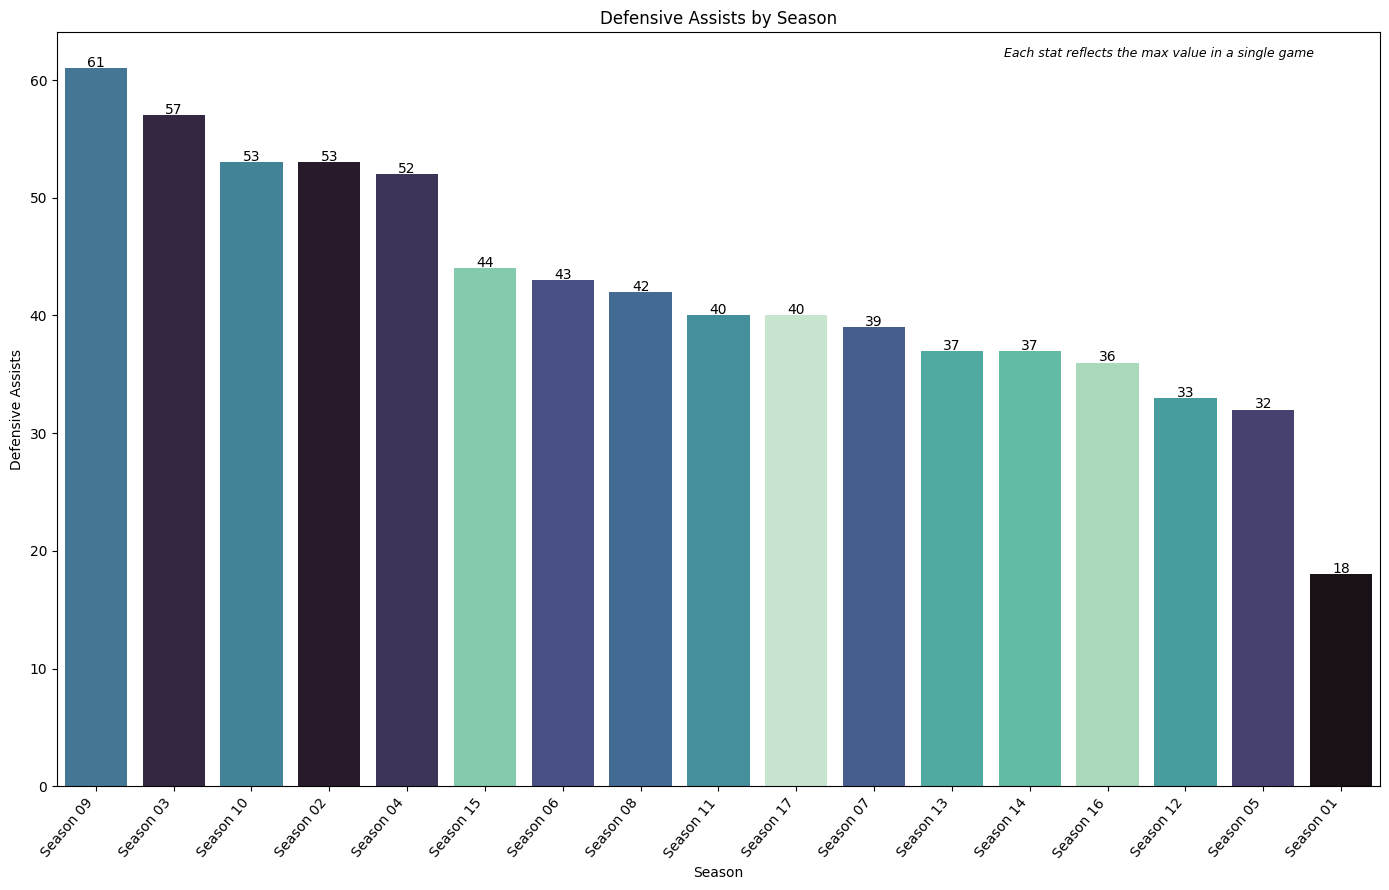

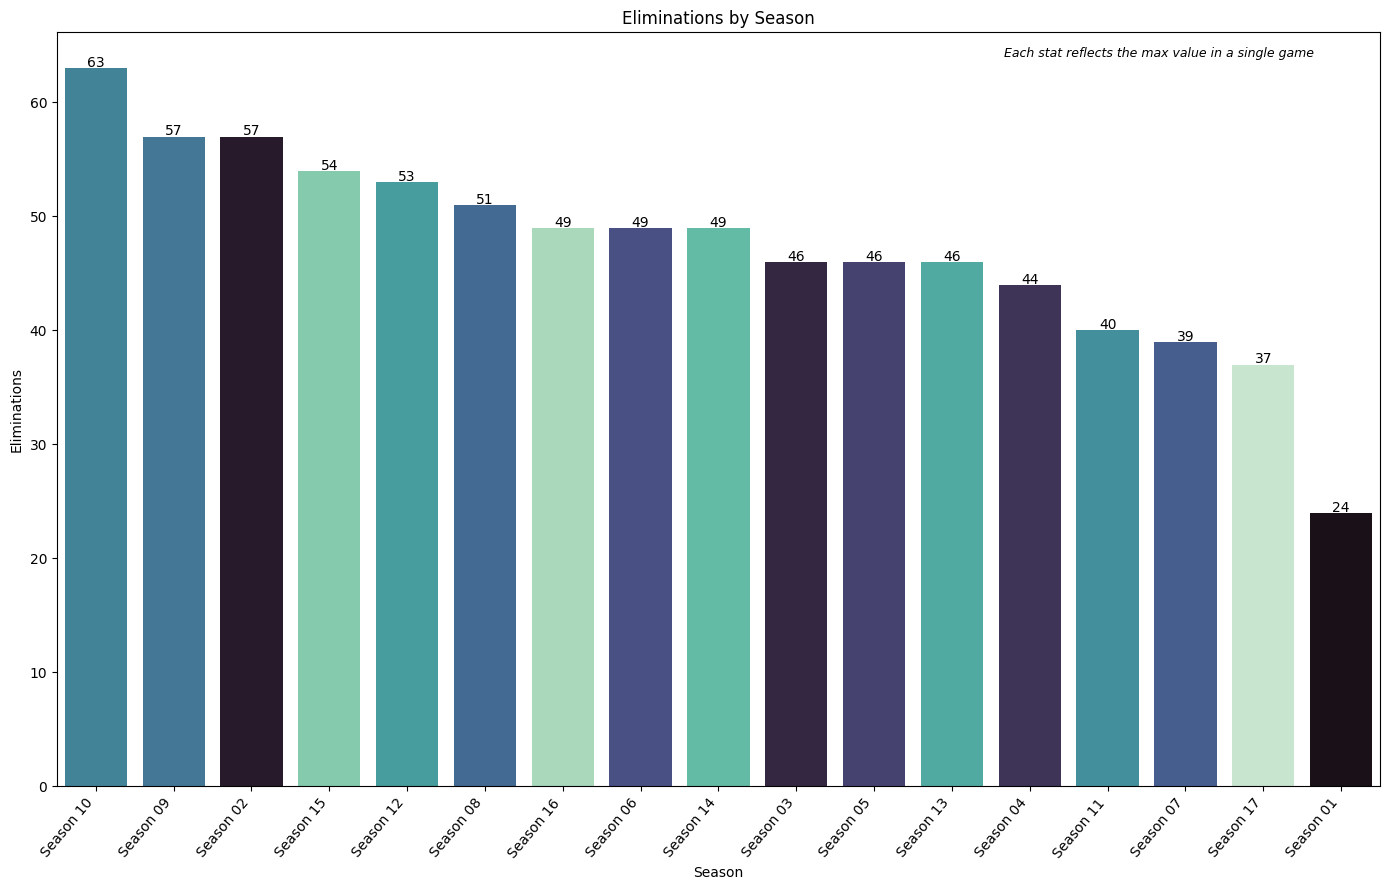

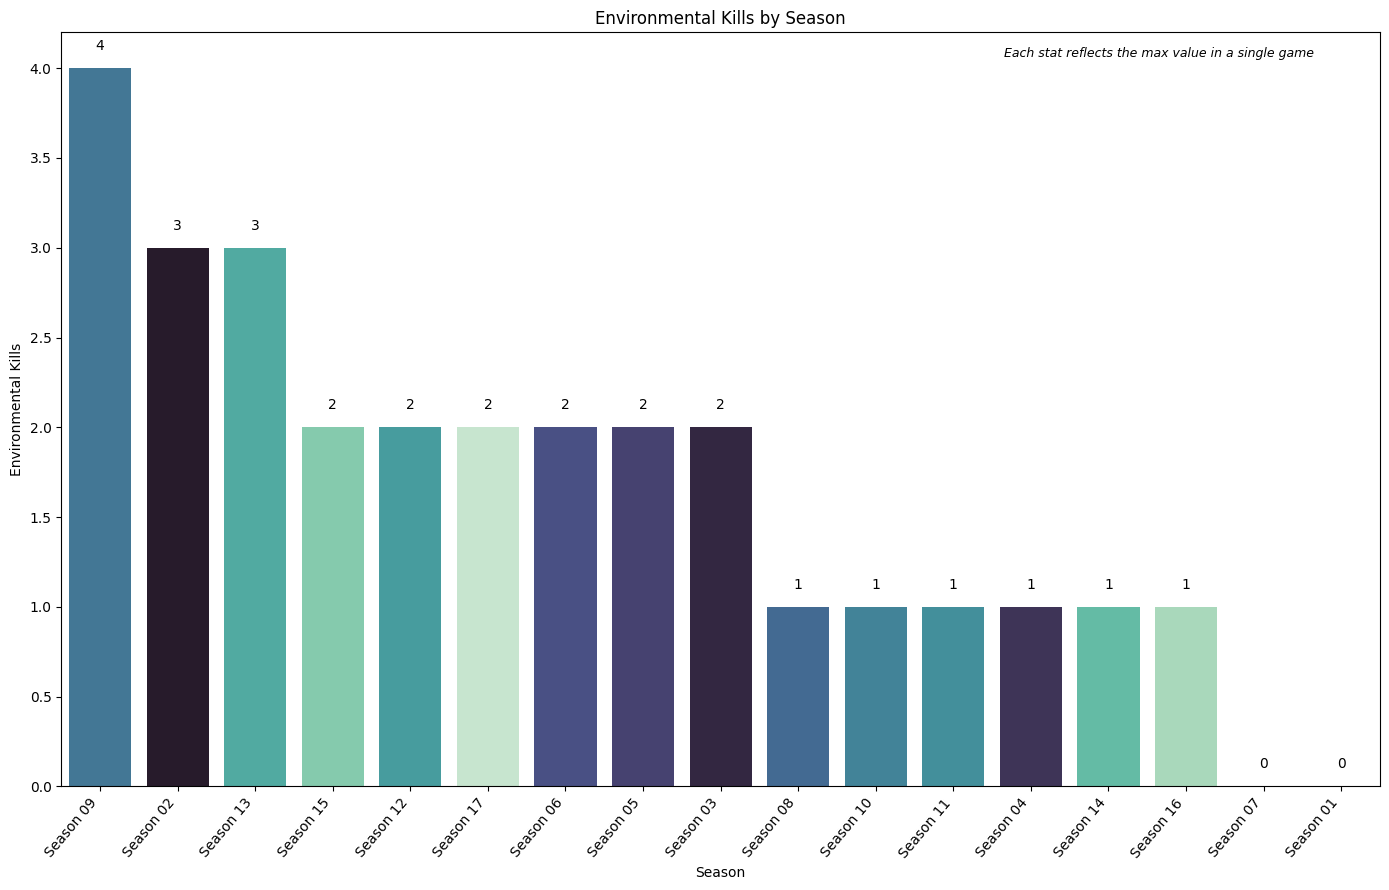

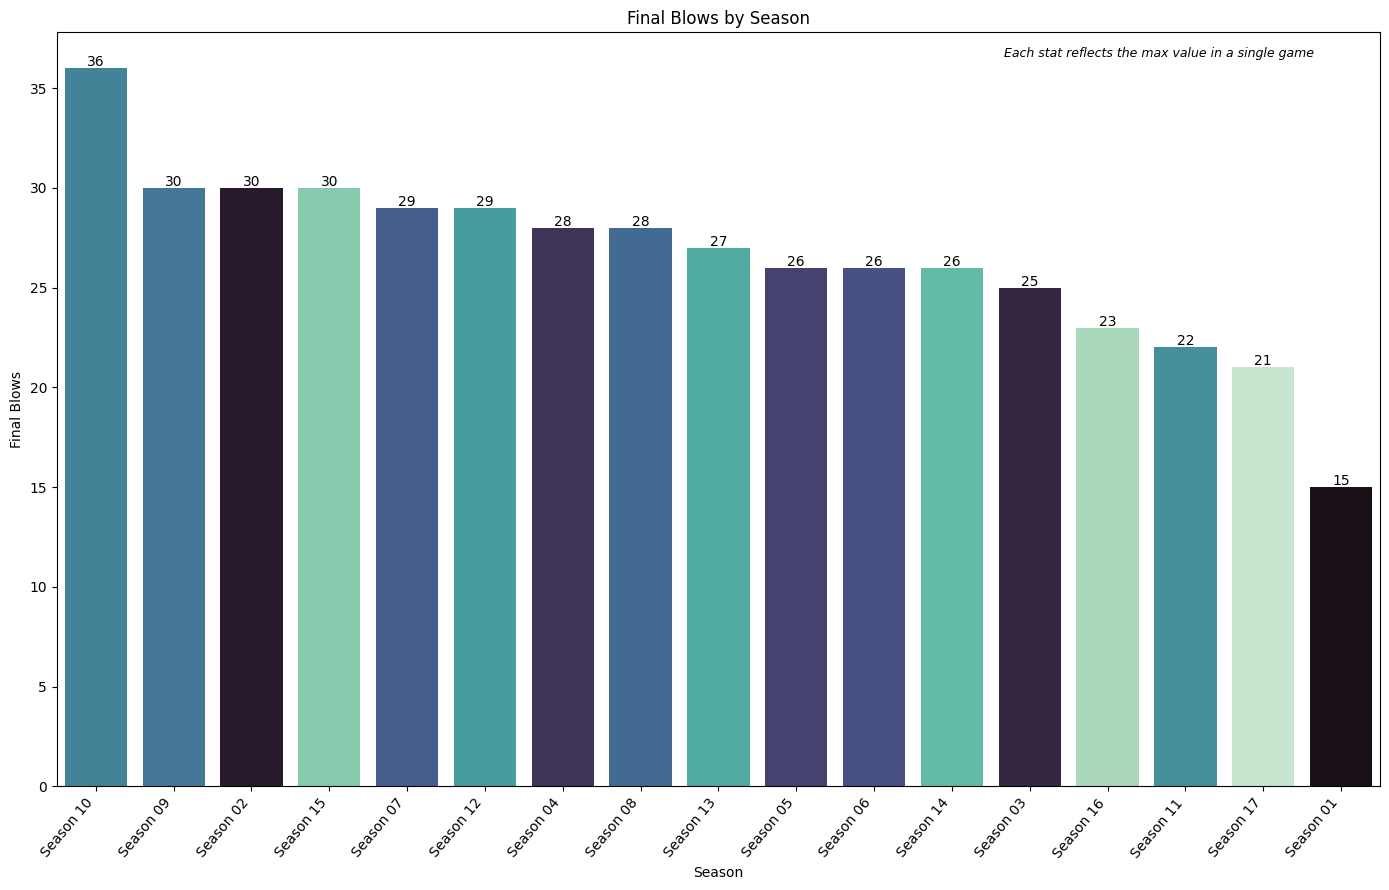

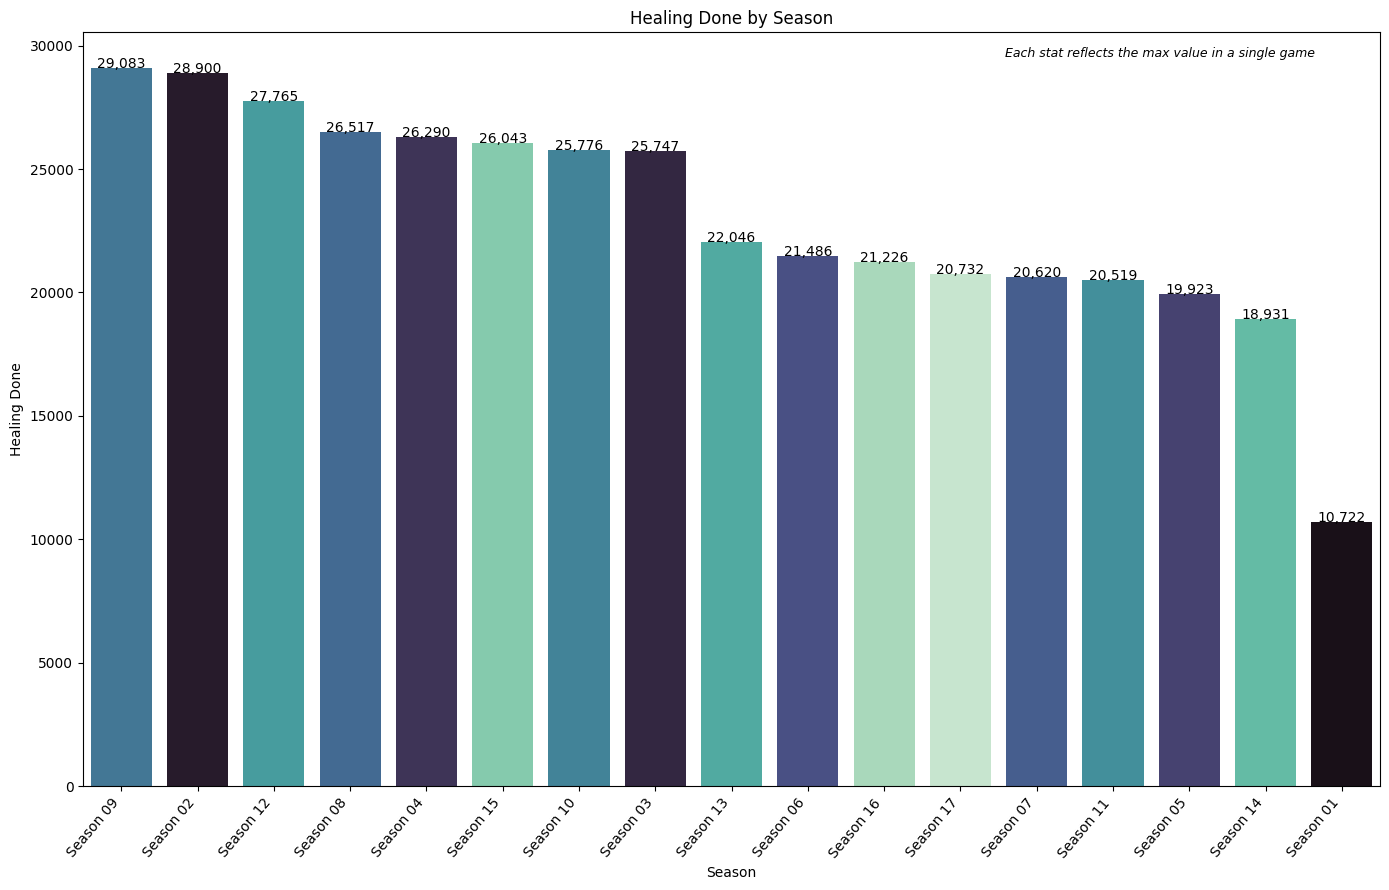

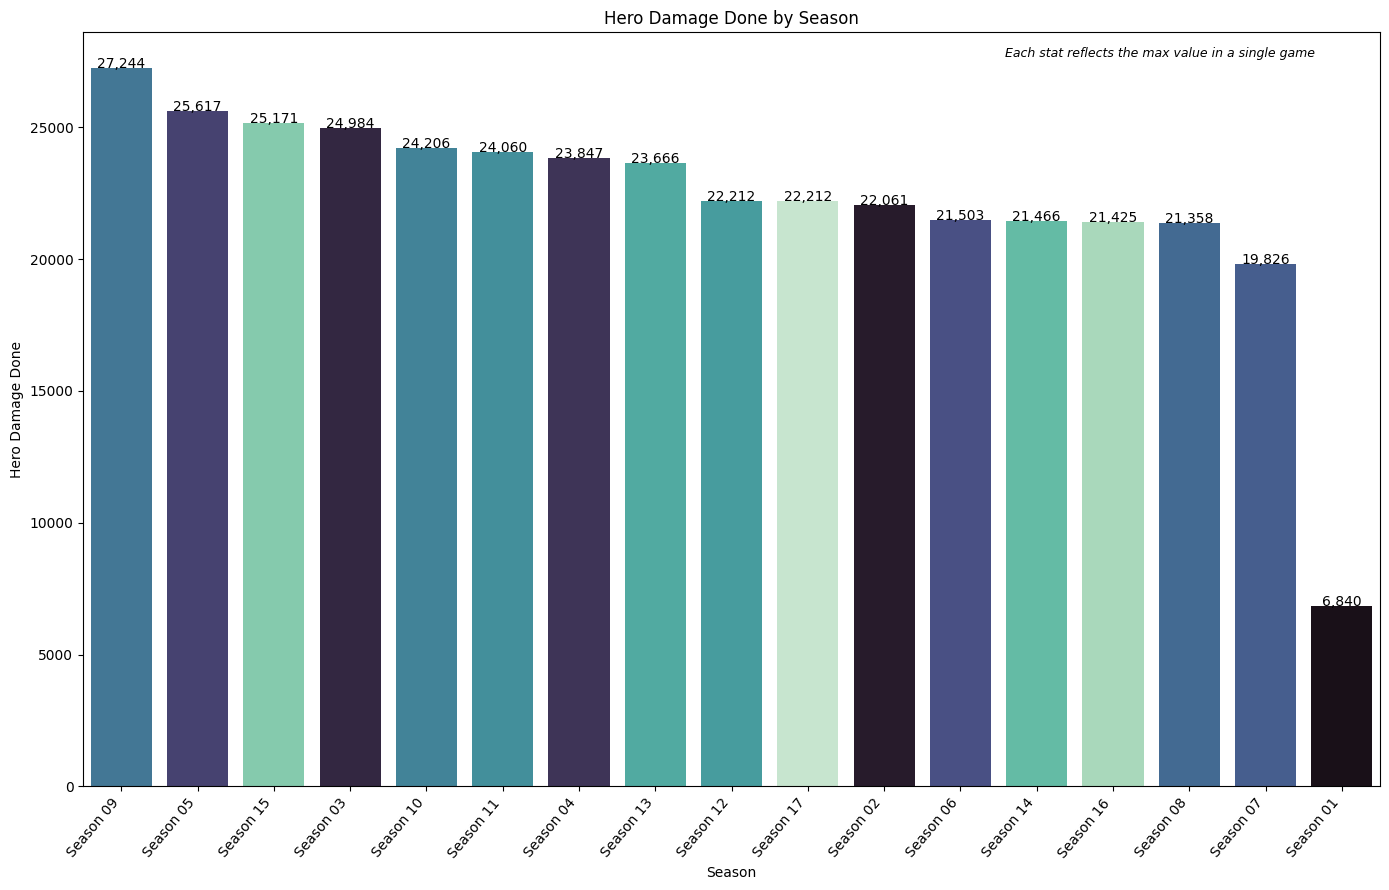

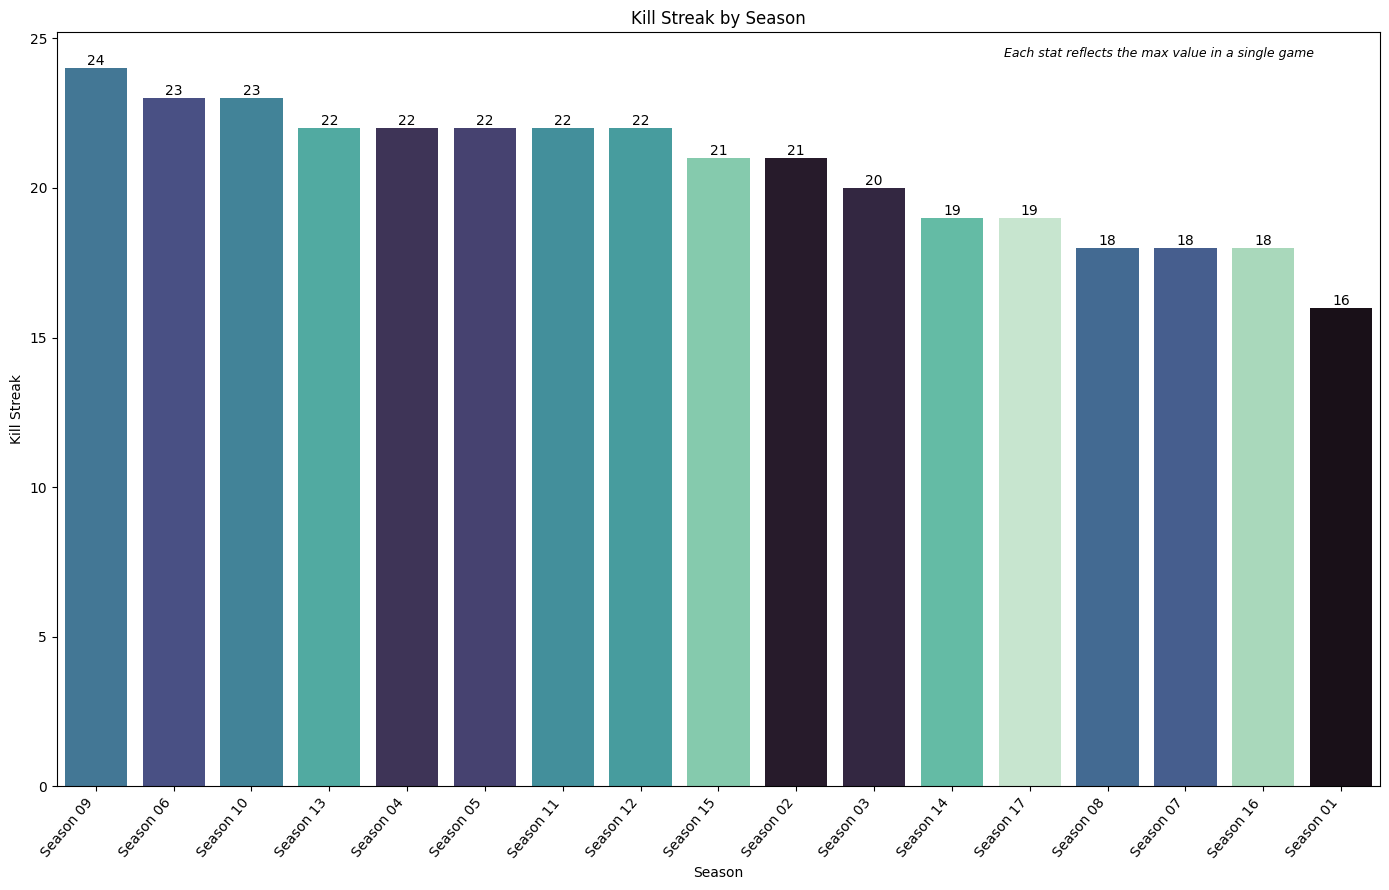

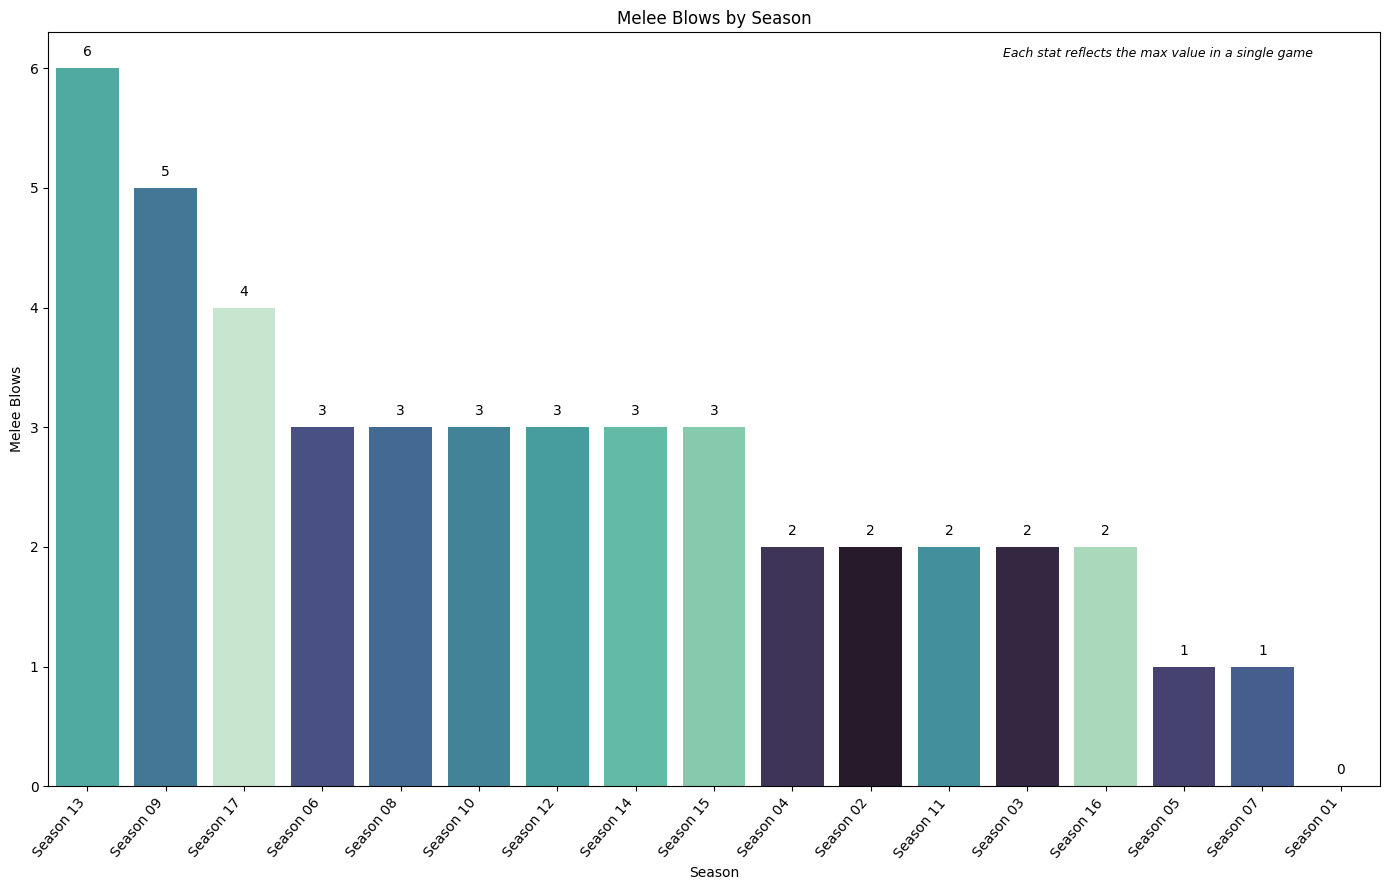

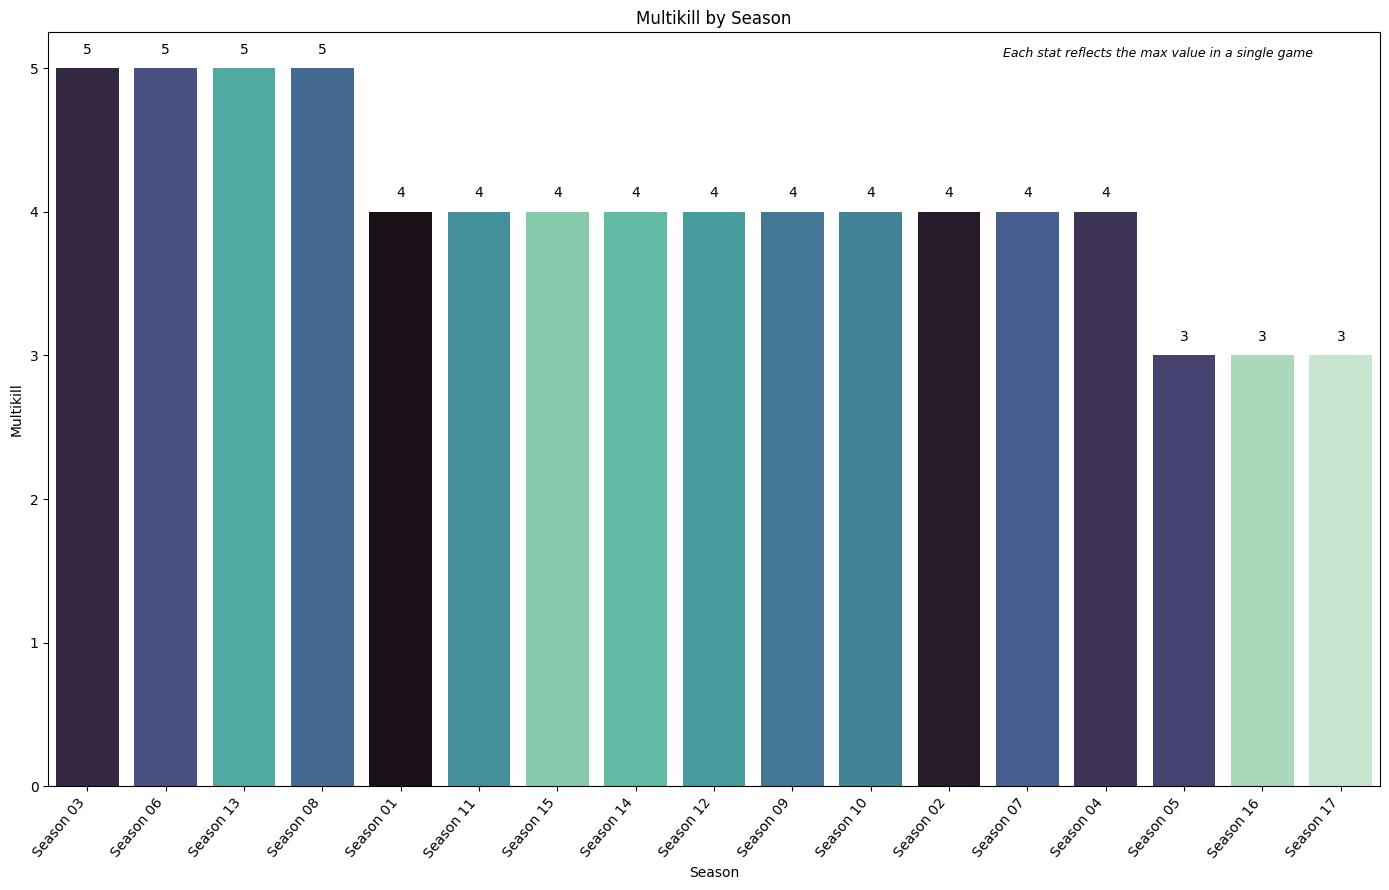

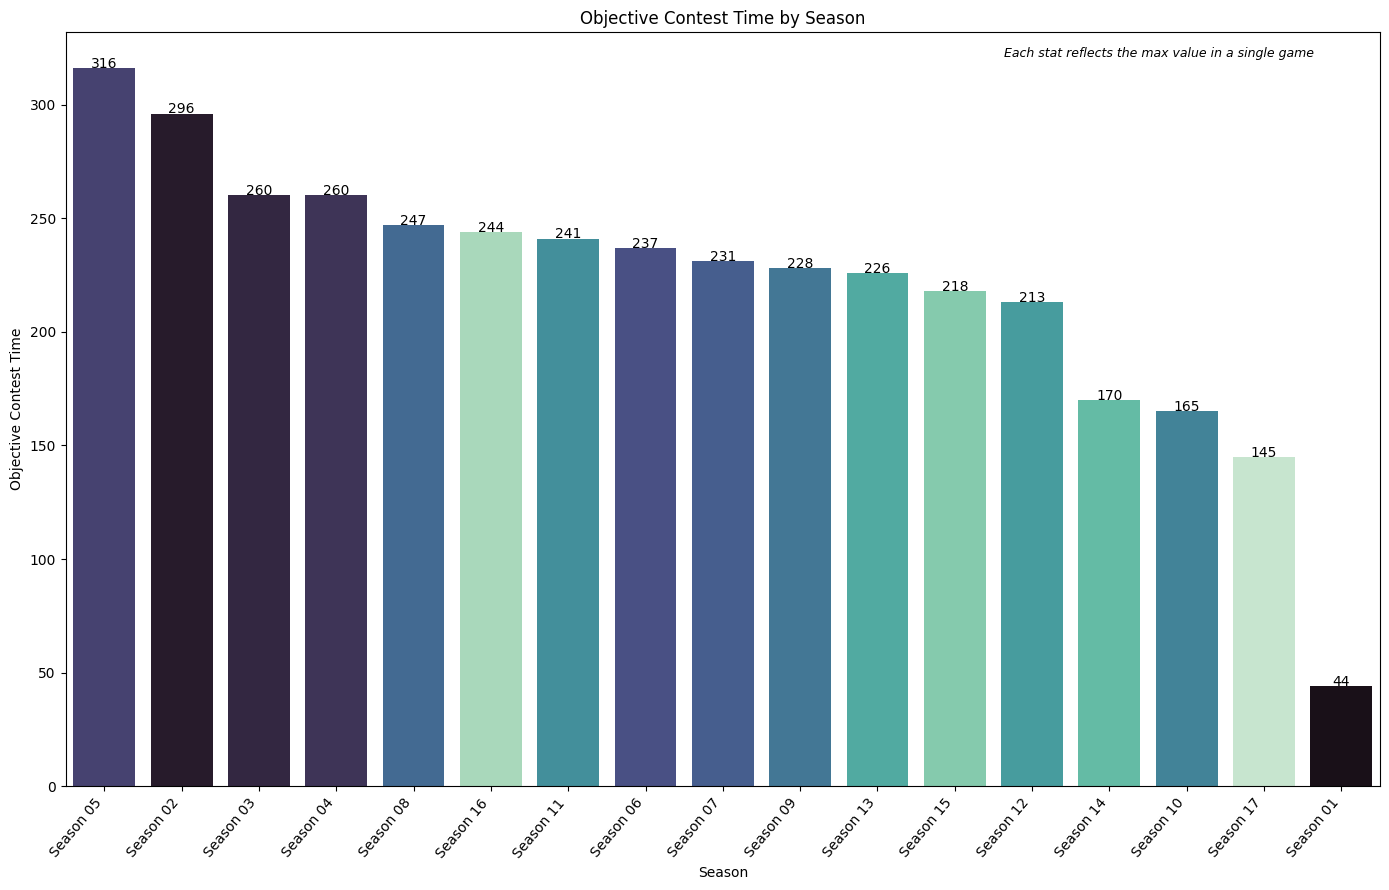

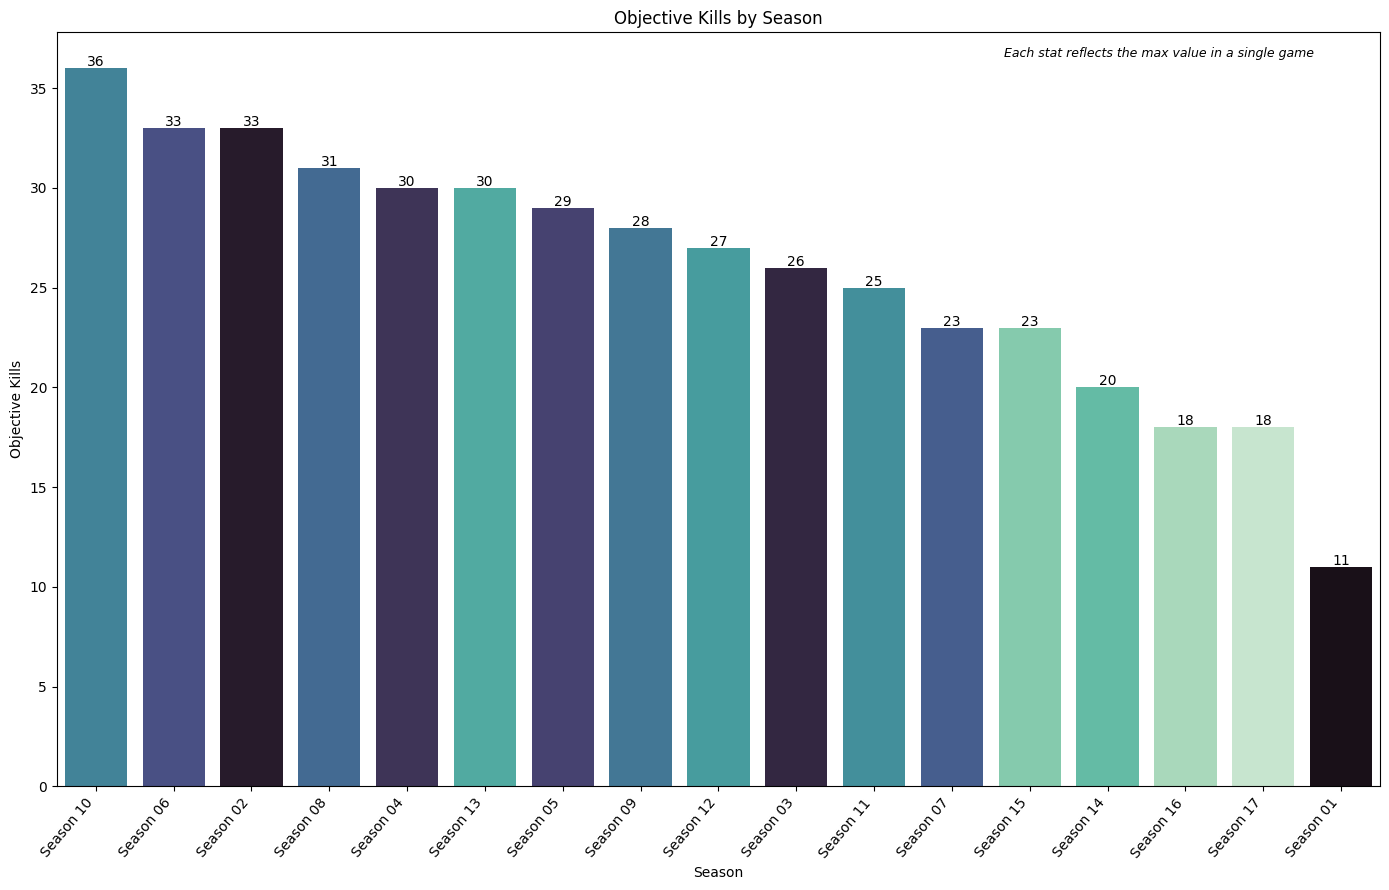

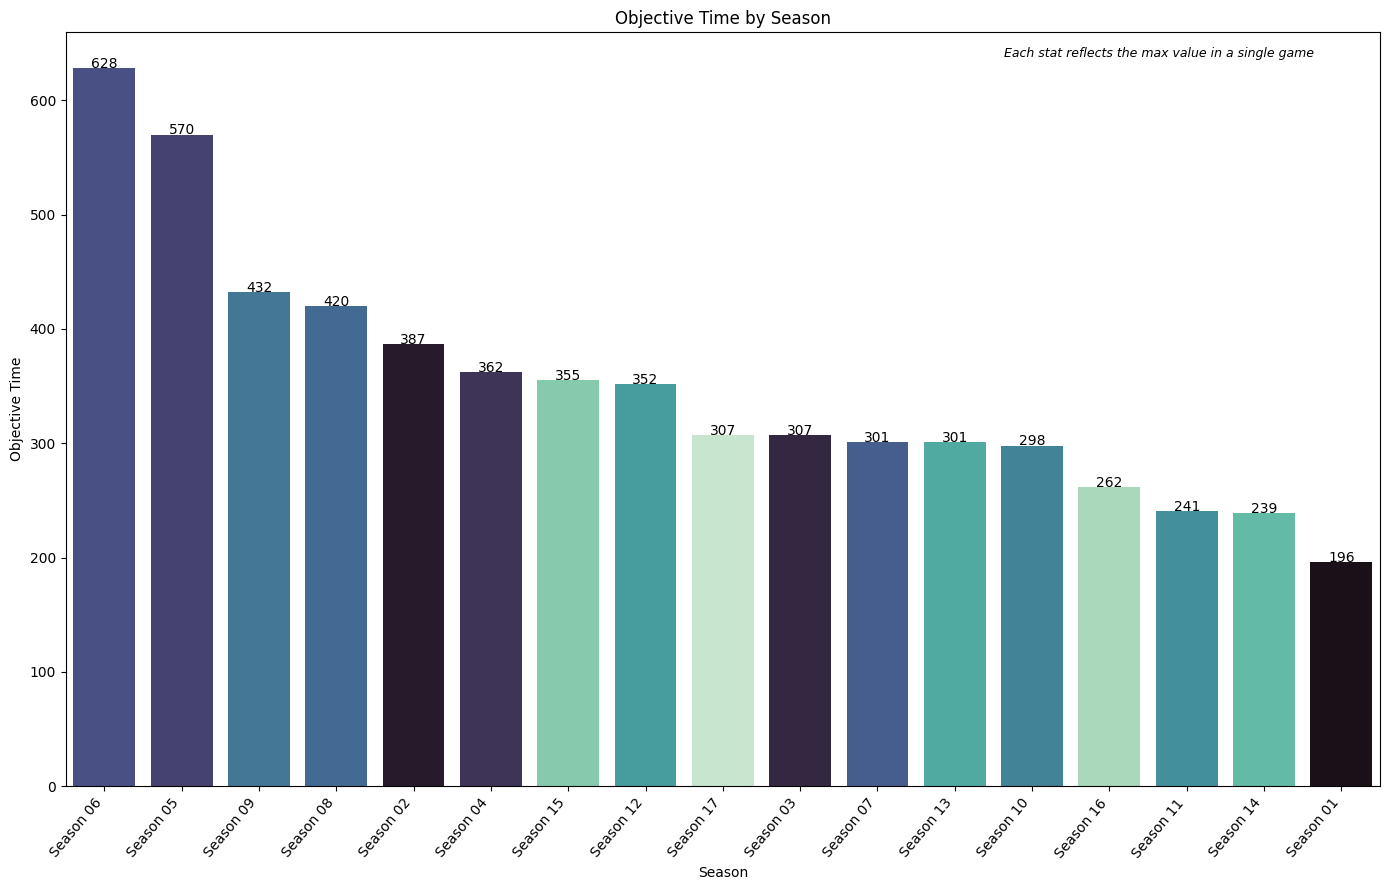

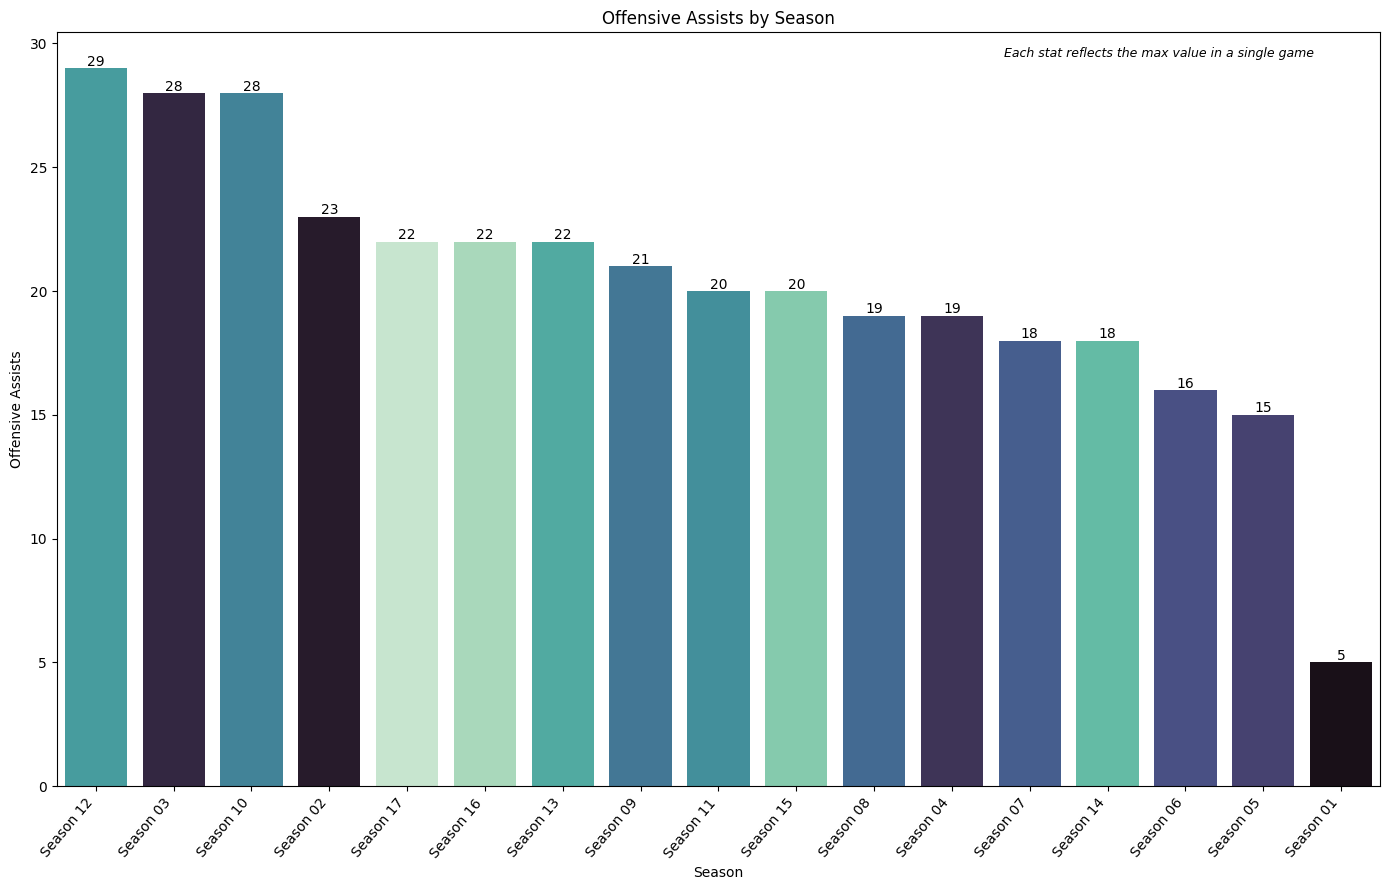

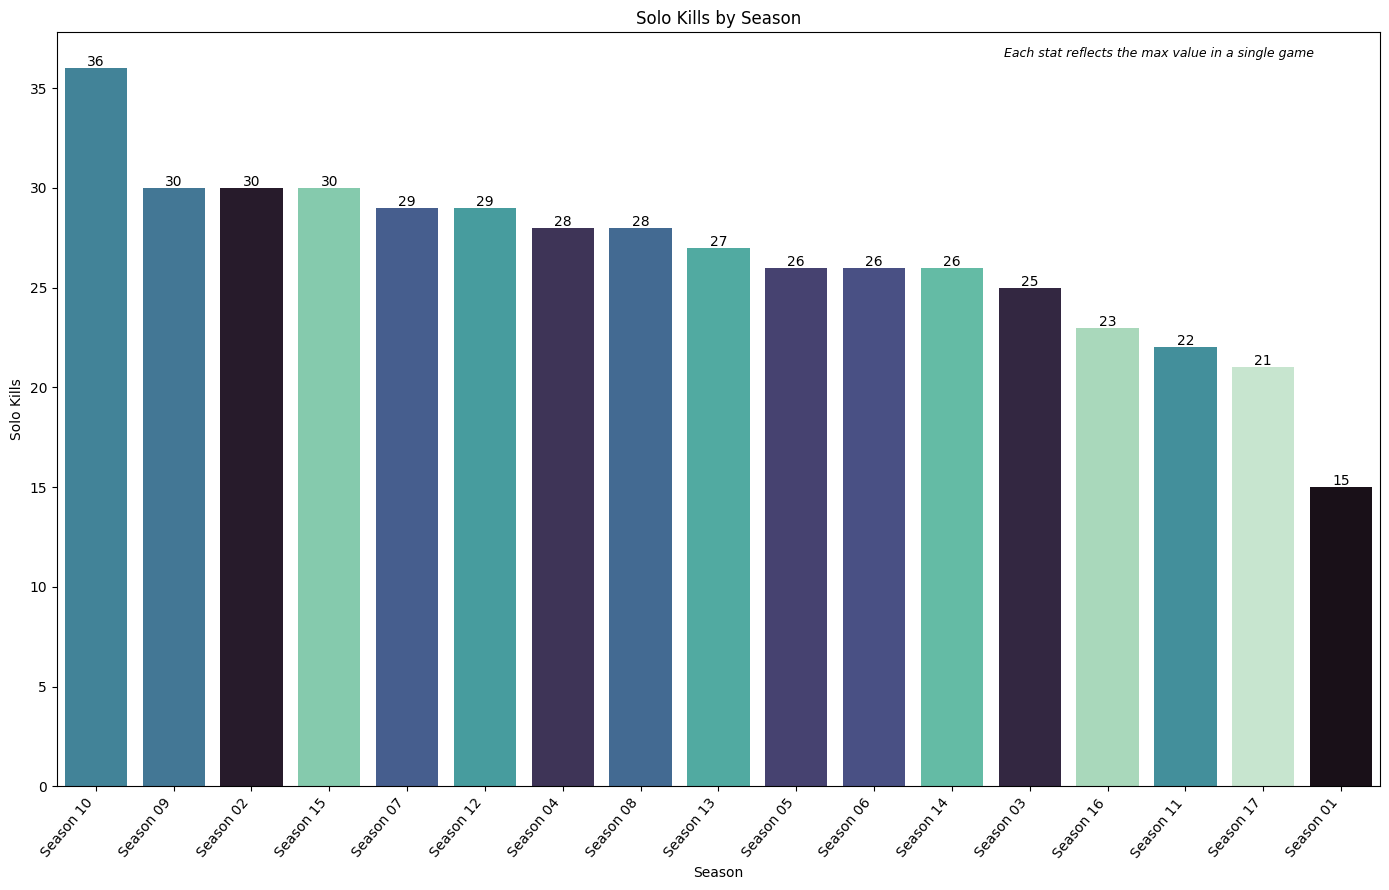

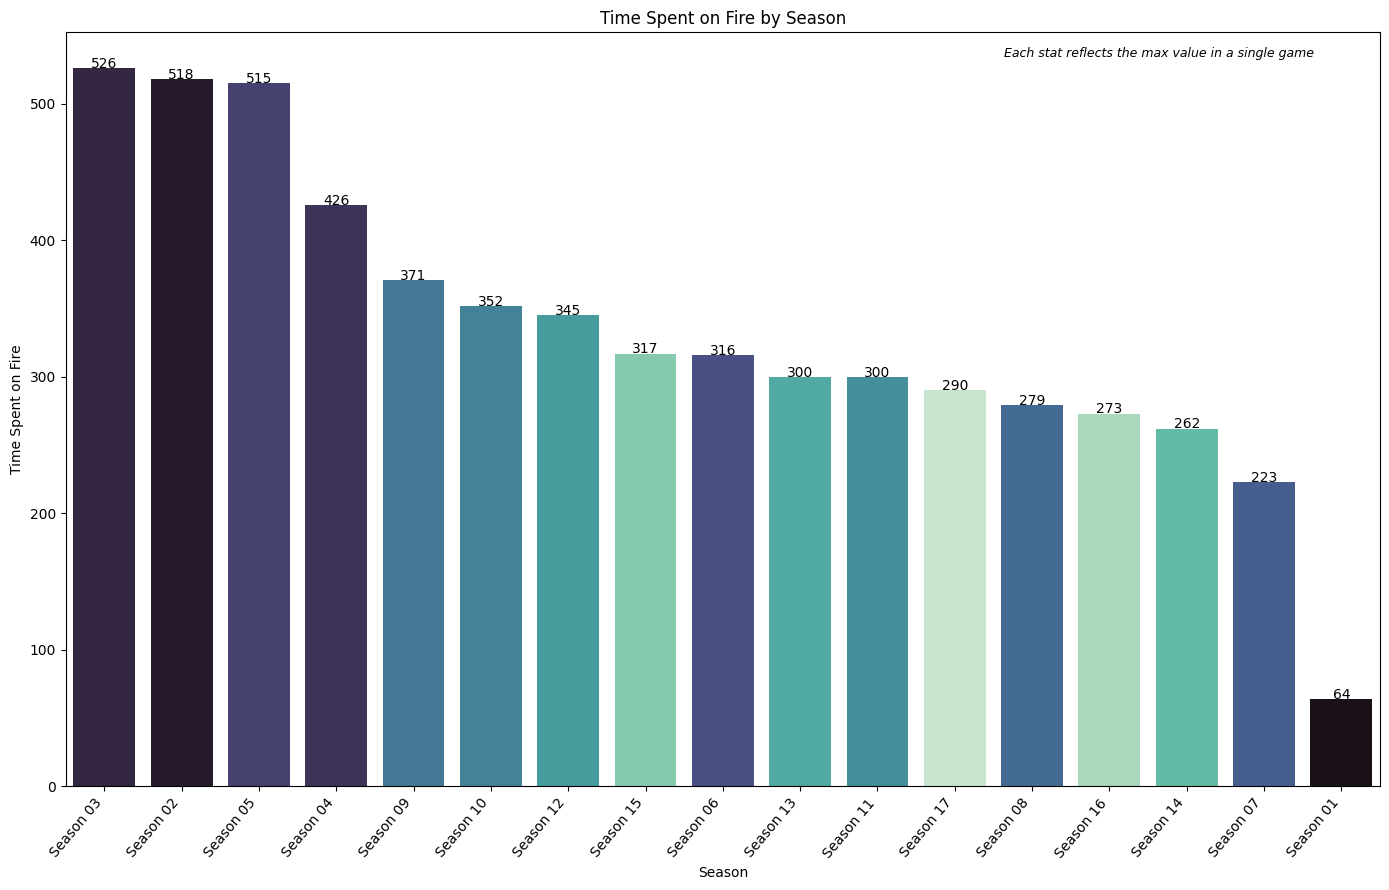

In [39]:
for column in clist2:
    
    #Create new figure for each column
    plt.figure(figsize=(14, 9)) 
    
    #Grouping by totals for custom ordering in graphs below
    order = pivoted.groupby('Season')[column].sum().sort_values(ascending=False).index
    
    ax = sns.barplot(data=pivoted, x='Season', y=column, hue='Season', palette='mako', estimator=sum, errorbar=None, order=order)

    # Annotate each bar with its height value above the bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,  # X coordinate: center of the bar
            height + 0.1,                    # Y coordinate: a bit above the bar
            f'{height:,.0f}',                # Text to display (formatted as int)
            ha='center',                     # Center alignment horizontally
            #rotation=35
            antialiased=True
        )
        
    plt.xticks(rotation=50, ha='right')
    plt.title(f'Total {column} per Season')
    plt.ylabel(f'{column}')
    plt.title(f'{column} by Season')
    ax.text(0.95, 0.98, "Each stat reflects the max value in a single game", transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic')
    plt.tight_layout()

In [40]:
corr = clist2.corr()
corr

Stat_Type,Assists,Barrier Damage Done,Damage Done,Defensive Assists,Eliminations,Environmental Kills,Final Blows,Healing Done,Hero Damage Done,Kill Streak,Melee Blows,Multikill,Objective Contest Time,Objective Kills,Objective Time,Offensive Assists,Solo Kills,Time Spent on Fire
Stat_Type,,,,,,,,,,,,,,,,,,
Assists,1.000000,0.653325,0.578144,0.952325,0.744872,0.506839,0.732707,0.856598,0.694962,0.597294,0.372575,0.346624,0.513339,0.677803,0.231117,0.621212,0.732707,0.599185
Barrier Damage Done,0.653325,1.000000,0.678946,0.645218,0.456518,0.579824,0.452988,0.612364,0.653523,0.683032,0.553640,0.519094,0.479250,0.720687,0.223219,0.594710,0.452988,0.574902
Damage Done,0.578144,0.678946,1.000000,0.519418,0.629124,0.392097,0.643585,0.710850,0.813503,0.718279,0.322950,0.276390,0.667399,0.693525,0.464819,0.623068,0.643585,0.650729
Defensive Assists,0.952325,0.645218,0.519418,1.000000,0.646562,0.508609,0.638909,0.797259,0.695657,0.560051,0.373553,0.258407,0.460006,0.610214,0.229741,0.592612,0.638909,0.642174
Eliminations,0.744872,0.456518,0.629124,0.646562,1.000000,0.512367,0.871883,0.811908,0.688537,0.614830,0.447838,0.132663,0.472079,0.717140,0.351992,0.669878,0.871883,0.537968
Environmental Kills,0.506839,0.579824,0.392097,0.508609,0.512367,1.000000,0.321825,0.583392,0.588670,0.648053,0.685857,0.121437,0.398156,0.423971,0.437349,0.386675,0.321825,0.558797
Final Blows,0.732707,0.452988,0.643585,0.638909,0.871883,0.321825,1.000000,0.776907,0.639853,0.590057,0.354525,0.194311,0.441609,0.776045,0.309605,0.609102,1.000000,0.471709
Healing Done,0.856598,0.612364,0.710850,0.797259,0.811908,0.583392,0.776907,1.000000,0.729894,0.580323,0.441776,0.222356,0.589292,0.695154,0.321384,0.750544,0.776907,0.659309
Hero Damage Done,0.694962,0.653523,0.813503,0.695657,0.688537,0.588670,0.639853,0.729894,1.000000,0.721567,0.519326,0.000851,0.709603,0.611435,0.385009,0.671700,0.639853,0.722357


<Axes: xlabel='Stat_Type', ylabel='Stat_Type'>

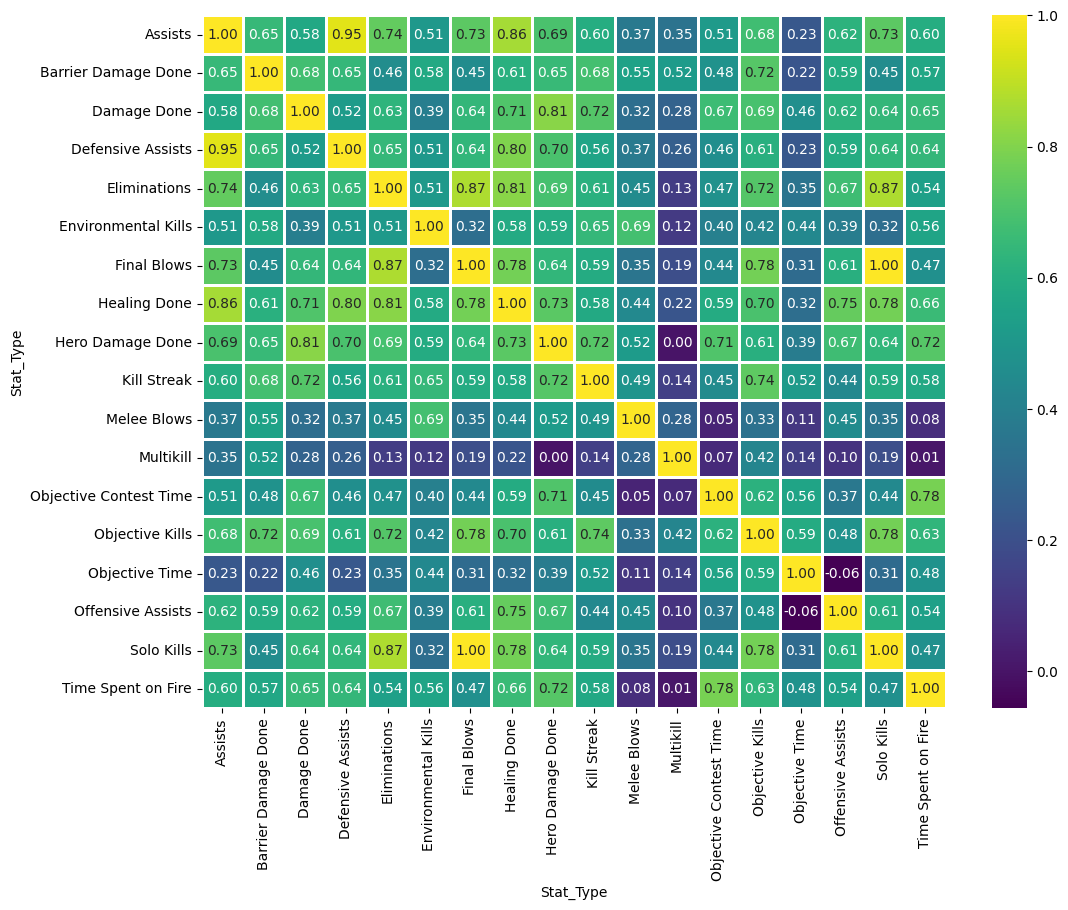

In [41]:
plt.figure(figsize=(12, 9)) 
sns.heatmap(data=corr, annot=True, fmt='.2f', linecolor='white', linewidths=1, cmap='viridis')

* We see a perfect correlation between Final Blows and Solo Kills
  * This makes sense because all solo kills are also final blows, but not all final blows are solo kills

## Player Hero Stat - Detail

In [42]:
player_small = tables_with_headers[50]

In [43]:
hero = player_small[1]

In [44]:
hero.head()

,Hero,Stat Context Type,Stat Context Name,Stat,Amount
0,Reaper,UNRANKED,NaN,Rpl {0}:Elimination:Eliminations;,213.000000
1,Reaper,UNRANKED,NaN,Time Played,5612.135683
2,Reaper,UNRANKED,NaN,Rpl {0}:Elimination:Eliminations; - Most in Life,23.000000
3,Reaper,UNRANKED,NaN,Rpl {0}:Death:Deaths;,51.000000
4,Reaper,UNRANKED,NaN,Final Rpl {0}:Blow:Blows;,115.000000


In [45]:
hero['Stat Context Type'].unique()

array(['UNRANKED', 'CUSTOM_GAME', 'VS_AI', 'RULESET'], dtype=object)

In [46]:
hero['Stat Context Name'].unique()

array([nan, 'Mystery Heroes', 'No Limits',
       'OW2 Ranked - Season 01 OpenQueue', 'Quick Play Open Queue',
       'OW2 Ranked - Season 02 OpenQueue', 'OW2 Ranked - Season 02',
       'OW2 Ranked - Season 03', 'OW2 Ranked - Season 04',
       'OW2 Ranked - Season 05', 'OW2 Ranked - Season 06',
       'OW2 Ranked - Season 07', 'OW2 Ranked - Season 08',
       'OW2 Ranked - Season 09', 'OW2 Ranked - Season 10',
       'OW2 Ranked - Season 11', 'OW2 Ranked - Season 12',
       'OW2 Ranked - Season 13', 'OW2 Ranked - Season 14',
       'OW2 Ranked - Season 15', 'OW2 Ranked - Season 16',
       'OW2 Ranked - Season 17', 'Hero Mastery - Easy',
       'Hero Mastery - Medium', 'Event Mission - London Fog',
       'OW2 Ranked - Season 01', 'OW2 Ranked - Season 11 OpenQueue',
       'OW2 Ranked - Season 15 OpenQueue', 'Low Gravity',
       'Extraction - Antarctica', 'OW2 Ranked - Season 16 OpenQueue',
       'OW2 Ranked - Season 13 OpenQueue', 'Deathmatch',
       'OW2 Ranked - Season 04 Open

In [47]:
#Filtering to records where Stat Context Name only has ranked values in it
hero = hero[hero['Stat Context Name'].str.contains('OW2 Ranked', case=False, na=False)]
hero = hero[~hero['Stat Context Name'].str.contains('Stadium|Open', case=False, na=False)]

In [48]:
sorted(hero['Stat Context Name'].unique())

['OW2 Ranked - Season 01',
 'OW2 Ranked - Season 02',
 'OW2 Ranked - Season 03',
 'OW2 Ranked - Season 04',
 'OW2 Ranked - Season 05',
 'OW2 Ranked - Season 06',
 'OW2 Ranked - Season 07',
 'OW2 Ranked - Season 08',
 'OW2 Ranked - Season 09',
 'OW2 Ranked - Season 10',
 'OW2 Ranked - Season 11',
 'OW2 Ranked - Season 12',
 'OW2 Ranked - Season 13',
 'OW2 Ranked - Season 14',
 'OW2 Ranked - Season 15',
 'OW2 Ranked - Season 16',
 'OW2 Ranked - Season 17']

In [49]:
sorted(hero['Stat'].unique())

['0x08600000000006CE',
 '0x08600000000007EB',
 '0x08600000000007EC',
 '0x086000000000080C',
 '0x0860000000000862',
 'Accretion Rpl {0}:Kill:Kills;',
 'Accretion Rpl {0}:Kill:Kills; - Most in Game',
 'Adaptive Shielding Created',
 'Adaptive Shielding Created - Most in Game',
 'All Damage Done',
 'All Damage Done - Most in Game',
 'All Damage Done - Most in Life',
 'Amplification Matrix Rpl {0}:Assist:Assists;',
 'Amplification Matrix Rpl {0}:Assist:Assists; - Best in Game',
 'Annihilation Rpl {0}:Kill:Kills;',
 'Annihilation Rpl {0}:Kill:Kills; - Most in Game',
 'Artillery Rpl {0}:Kill:Kills;',
 'Artillery Rpl {0}:Kill:Kills; - Most in Game',
 'Assault Rpl {0}:Kill:Kills;',
 'Average Energy - Best in Game',
 'Barrage Rpl {0}:Kill:Kills;',
 'Barrage Rpl {0}:Kill:Kills; - Most in Game',
 'Biotic Grenade Rpl {0}:Kill:Kills;',
 'Biotic Orb Rpl {0}:Kill:Kills;',
 'Biotic Orb Rpl {0}:Kill:Kills; - Most in Game',
 'Blaster Rpl {0}:Kill:Kills;',
 'Blaster Rpl {0}:Kill:Kills; - Most in Game',
 '

In [50]:
hero['Stat'] = hero['Stat'].str.replace(r'Rpl\s*\{\s*0\s*\}|All', '', regex=True).str.strip()

In [51]:
sorted(hero['Stat'].unique())

['0x08600000000006CE',
 '0x08600000000007EB',
 '0x08600000000007EC',
 '0x086000000000080C',
 '0x0860000000000862',
 ':Assist:Assists;',
 ':Assist:Assists; - Most in Game',
 ':Death:Deaths;',
 ':Elimination:Eliminations;',
 ':Elimination:Eliminations; - Most in Game',
 ':Elimination:Eliminations; - Most in Life',
 ':Enemy:Enemies; Frozen',
 ':Enemy:Enemies; Frozen - Most in Game',
 ':Enemy:Enemies; Hacked',
 ':Enemy:Enemies; Hacked - Most in Game',
 ':Enemy:Enemies; Slept',
 ':Enemy:Enemies; Slept - Most in Game',
 ':Enemy:Enemies; Trapped',
 ':Enemy:Enemies; Trapped - Most in Game',
 ':Game:Games; Played',
 ':Game:Games; Tied',
 ':Game:Games; Won',
 ':Multikill:Multikills;',
 ':Overhealth:Overhealth; Created',
 ':Overhealth:Overhealth; Created - Most in Game',
 ':Player:Players; Knocked Back',
 ':Player:Players; Knocked Back - Most in Game',
 ':Player:Players; Knocked Back - Most in Game NYI',
 ':Player:Players; Resurrected',
 ':Player:Players; Resurrected - Most in Game',
 ':Player:Pl

In [52]:
def clean_stat_full(s):
    s = s.strip()

    # Capture trailing description starting with " -", if any
    trailing_desc = ""
    if " - " in s:
        s, trailing_desc = s.split(" - ", 1)
        trailing_desc = " - " + trailing_desc.strip()

    # Remove substring(s) wrapped in colons, but keep the text after the last colon group
    # Pattern explanation:
    #   Match colon-wrapped groups: colon, any non-colon chars, colon (like ":Kill:")
    #   We want to remove all such colon-wrapped groups except keep the last word after last colon group
    #   So first, remove all colon-wrapped groups
    s_no_colon_groups = re.sub(r':[^\s:]+:', ' ', s)

    # After removing colon groups, multiple spaces or trailing semicolons might remain
    s_no_colon_groups = s_no_colon_groups.replace(';', ' ')  # remove semicolons
    s_no_colon_groups = re.sub(r'\s+', ' ', s_no_colon_groups).strip()

    # Now append trailing description back
    result = f"{s_no_colon_groups}{trailing_desc}".strip()
    return result

# Apply it
hero['Stat_Type'] = hero['Stat'].apply(clean_stat_full)

In [53]:
sorted(hero['Stat_Type'].unique())

['0x08600000000006CE',
 '0x08600000000007EB',
 '0x08600000000007EC',
 '0x086000000000080C',
 '0x0860000000000862',
 'Accretion Kills',
 'Accretion Kills - Most in Game',
 'Adaptive Shielding Created',
 'Adaptive Shielding Created - Most in Game',
 'Amplification Matrix Assists',
 'Amplification Matrix Assists - Best in Game',
 'Annihilation Kills',
 'Annihilation Kills - Most in Game',
 'Artillery Kills',
 'Artillery Kills - Most in Game',
 'Assault Kills',
 'Assists',
 'Assists - Most in Game',
 'Average Energy - Best in Game',
 'Barrage Kills',
 'Barrage Kills - Most in Game',
 'Biotic Grenade Kills',
 'Biotic Orb Kills',
 'Biotic Orb Kills - Most in Game',
 'Blaster Kills',
 'Blaster Kills - Most in Game',
 'Blizzard Kills',
 'Blizzard Kills - Most in Game',
 'Bob Kills',
 'Bob Kills - Most in Game',
 'Burrow Kills',
 'Burrow Kills - Most in Game',
 'Cage Fight Kills',
 'Cage Fight Kills - Most in Game',
 'Call Mech Kills',
 'Call Mech Kills - Most in Game',
 'Captive Sun Damage - M

In [54]:
hero.head()

,Hero,Stat Context Type,Stat Context Name,Stat,Amount,Stat_Type
300,Reaper,RULESET,OW2 Ranked - Season 02,:Elimination:Eliminations;,93.000000,Eliminations
301,Reaper,RULESET,OW2 Ranked - Season 02,Time Played,2752.825135,Time Played
302,Reaper,RULESET,OW2 Ranked - Season 02,:Elimination:Eliminations; - Most in Life,15.000000,Eliminations - Most in Life
303,Reaper,RULESET,OW2 Ranked - Season 02,:Death:Deaths;,36.000000,Deaths
304,Reaper,RULESET,OW2 Ranked - Season 02,Final :Blow:Blows;,53.000000,Final Blows


In [55]:
hero['Hero'].unique()

array(['Reaper', 'Tracer', 'Mercy', 'Hanzo', 'Torbjörn', 'Reinhardt',
       'Pharah', 'Winston', 'Widowmaker', 'Bastion', 'Symmetra',
       'Zenyatta', 'Genji', 'Roadhog', 'Cassidy', 'Junkrat', 'Zarya',
       'Soldier: 76', 'Lúcio', 'D.Va', 'Mei', 'Sombra', 'Doomfist', 'Ana',
       'Orisa', 'Brigitte', 'Moira', 'Wrecking Ball', 'Sojourn', 'Ashe',
       'Echo', 'Baptiste', 'Kiriko', 'Junker Queen', 'Sigma', 'Ramattra',
       'Lifeweaver', 'Mauga', 'Illari', 'Freja', 'Venture', 'Hazard',
       'Juno'], dtype=object)

In [56]:
role_groups = {
    'Damage': ['Reaper', 'Tracer', 'Hanzo', 'Torbjörn', 'Pharah', 'Widowmaker', 'Bastion',
               'Symmetra', 'Genji', 'Cassidy', 'Junkrat', 'Soldier: 76', 'Mei', 'Sombra',
               'Sojourn', 'Ashe', 'Echo', 'Venture', 'Freja'],
    'Support': ['Mercy', 'Zenyatta', 'Lúcio', 'Ana', 'Brigitte', 'Moira', 'Baptiste',
                'Kiriko', 'Lifeweaver', 'Illari', 'Juno'],
    'Tank': ['Reinhardt', 'Winston', 'Roadhog', 'Zarya', 'D.Va', 'Doomfist', 'Orisa',
             'Wrecking Ball', 'Junker Queen', 'Sigma', 'Ramattra', 'Mauga', 'Hazard']
}

role_map = {hero: role for role, heroes in role_groups.items() for hero in heroes}
hero['Role'] = hero['Hero'].map(role_map)

In [57]:
hero.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24166 entries, 300 to 36577
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Hero               24166 non-null  object 
 1   Stat Context Type  24166 non-null  object 
 2   Stat Context Name  24166 non-null  object 
 3   Stat               24166 non-null  object 
 4   Amount             24166 non-null  float64
 5   Stat_Type          24166 non-null  object 
 6   Role               24166 non-null  object 
dtypes: float64(1), object(6)
memory usage: 1.5+ MB


In [58]:
hero['Season'] = hero['Stat Context Name'].apply(lambda x: ' '.join(x.split(' ')[3:5]))
hero.drop(["Stat Context Name", "Stat", "Stat Context Type"], axis=1, inplace=True)

In [59]:
hero = hero[['Season', 'Hero', 'Role', 'Stat_Type', 'Amount']]
hero.head()

,Season,Hero,Role,Stat_Type,Amount
300,Season 02,Reaper,Damage,Eliminations,93.000000
301,Season 02,Reaper,Damage,Time Played,2752.825135
302,Season 02,Reaper,Damage,Eliminations - Most in Life,15.000000
303,Season 02,Reaper,Damage,Deaths,36.000000
304,Season 02,Reaper,Damage,Final Blows,53.000000


In [60]:
sorted(hero['Stat_Type'].unique())

['0x08600000000006CE',
 '0x08600000000007EB',
 '0x08600000000007EC',
 '0x086000000000080C',
 '0x0860000000000862',
 'Accretion Kills',
 'Accretion Kills - Most in Game',
 'Adaptive Shielding Created',
 'Adaptive Shielding Created - Most in Game',
 'Amplification Matrix Assists',
 'Amplification Matrix Assists - Best in Game',
 'Annihilation Kills',
 'Annihilation Kills - Most in Game',
 'Artillery Kills',
 'Artillery Kills - Most in Game',
 'Assault Kills',
 'Assists',
 'Assists - Most in Game',
 'Average Energy - Best in Game',
 'Barrage Kills',
 'Barrage Kills - Most in Game',
 'Biotic Grenade Kills',
 'Biotic Orb Kills',
 'Biotic Orb Kills - Most in Game',
 'Blaster Kills',
 'Blaster Kills - Most in Game',
 'Blizzard Kills',
 'Blizzard Kills - Most in Game',
 'Bob Kills',
 'Bob Kills - Most in Game',
 'Burrow Kills',
 'Burrow Kills - Most in Game',
 'Cage Fight Kills',
 'Cage Fight Kills - Most in Game',
 'Call Mech Kills',
 'Call Mech Kills - Most in Game',
 'Captive Sun Damage - M

In [61]:
hero = hero[~hero['Stat_Type'].str.startswith('0x', na=False)]

In [62]:
sorted(hero['Stat_Type'].unique())

['Accretion Kills',
 'Accretion Kills - Most in Game',
 'Adaptive Shielding Created',
 'Adaptive Shielding Created - Most in Game',
 'Amplification Matrix Assists',
 'Amplification Matrix Assists - Best in Game',
 'Annihilation Kills',
 'Annihilation Kills - Most in Game',
 'Artillery Kills',
 'Artillery Kills - Most in Game',
 'Assault Kills',
 'Assists',
 'Assists - Most in Game',
 'Average Energy - Best in Game',
 'Barrage Kills',
 'Barrage Kills - Most in Game',
 'Biotic Grenade Kills',
 'Biotic Orb Kills',
 'Biotic Orb Kills - Most in Game',
 'Blaster Kills',
 'Blaster Kills - Most in Game',
 'Blizzard Kills',
 'Blizzard Kills - Most in Game',
 'Bob Kills',
 'Bob Kills - Most in Game',
 'Burrow Kills',
 'Burrow Kills - Most in Game',
 'Cage Fight Kills',
 'Cage Fight Kills - Most in Game',
 'Call Mech Kills',
 'Call Mech Kills - Most in Game',
 'Captive Sun Damage - Most in Game',
 'Carnage Kills',
 'Carnage Kills - Most in Game',
 'Chain Hook Accuracy - Best in Game',
 'Chain Hoo

## Initial Analysis before deciding to switch to Power BI

In [63]:
hero_metrics = set([
'Assist',
'Assist - Most in Game',
'Assists', 'Critical Hit',
'Critical Hit - Most in Game',
'Critical Hit - Most in Life',
'Critical Hit Damage',
'Critical Hit Damage - Most in Game',
'Critical Hit Kill',
'Critical Hit Kill - Most in Game',
'Critical Kills',
'Damage Done',
'Damage Done - Most in Game',
'Damage Done - Most in Life',
'Death',
'Defensive Assist',
'Defensive Assist - Most in Game',
'Elimination',
'Elimination - Most in Game',
'Elimination - Most in Life', 
'Final Blow',
'Games Played',
'Games Tied',
'Games Won',
'Healing Done',
'Healing Done - Most in Game',
'Hero',
'Hero Damage Done', 
'Hero Wins', 
'Kill Streak - Best',
'Melee Blow',
'Obj Contest Time',
'Obj Contest Time - Most in Game',
'Objective Kill', 
'Objective Kill - Most in Game',
'Objective Time',
'Objective Time - Most in Game', 
'Offensive Assist', 
'Offensive Assist - Most in Game',
'Scoped Accuracy - Best in Game',
'Self Healing',
'Solo Kill',
'Time Played',
'Time Spent on Fire',
'Weapon Accuracy'
])
hero_metrics = sorted(hero_metrics)
print(hero_metrics)

['Assist', 'Assist - Most in Game', 'Assists', 'Critical Hit', 'Critical Hit - Most in Game', 'Critical Hit - Most in Life', 'Critical Hit Damage', 'Critical Hit Damage - Most in Game', 'Critical Hit Kill', 'Critical Hit Kill - Most in Game', 'Critical Kills', 'Damage Done', 'Damage Done - Most in Game', 'Damage Done - Most in Life', 'Death', 'Defensive Assist', 'Defensive Assist - Most in Game', 'Elimination', 'Elimination - Most in Game', 'Elimination - Most in Life', 'Final Blow', 'Games Played', 'Games Tied', 'Games Won', 'Healing Done', 'Healing Done - Most in Game', 'Hero', 'Hero Damage Done', 'Hero Wins', 'Kill Streak - Best', 'Melee Blow', 'Obj Contest Time', 'Obj Contest Time - Most in Game', 'Objective Kill', 'Objective Kill - Most in Game', 'Objective Time', 'Objective Time - Most in Game', 'Offensive Assist', 'Offensive Assist - Most in Game', 'Scoped Accuracy - Best in Game', 'Self Healing', 'Solo Kill', 'Time Played', 'Time Spent on Fire', 'Weapon Accuracy']


In [64]:
main_stats = hero[hero['Stat_Type'].isin(hero_metrics)]
main_stats.reset_index(drop=True, inplace=True)
main_stats

,Season,Hero,Role,Stat_Type,Amount
0,Season 02,Reaper,Damage,Time Played,2752.825135
1,Season 02,Reaper,Damage,Damage Done - Most in Life,3060.253916
2,Season 02,Reaper,Damage,Games Played,4.770113
3,Season 02,Reaper,Damage,Games Won,1.256112
4,Season 02,Reaper,Damage,Damage Done,43675.227680
...,...,...,...,...,...
10173,Season 17,Juno,Support,Obj Contest Time - Most in Game,2.624000
10174,Season 17,Juno,Support,Games Won,0.793258
10175,Season 17,Juno,Support,Games Won,0.793258
10176,Season 17,Juno,Support,Hero Wins,0.793258


* Below pivot has a lot of missing data, especially in early seasons.
* Missing because of playing open queue as well as role queue, but open queue is filtered out from the below data 

In [65]:
pd.set_option('display.max_columns', None)

hero_piv = main_stats.pivot_table(
    index=['Season', 'Hero', 'Role'],   # columns to keep as rows
    columns='Stat_Type',                # values that become new columns
    values='Amount',                    # values to fill in those new columns
    aggfunc='first'                     # in case of duplicates, just take the first
).reset_index()
hero_piv = hero_piv.fillna(0)
hero_piv.head()

Stat_Type,Season,Hero,Role,Assists,Critical Hit Damage,Critical Hit Damage - Most in Game,Damage Done,Damage Done - Most in Game,Damage Done - Most in Life,Games Played,Games Tied,Games Won,Healing Done,Healing Done - Most in Game,Hero Damage Done,Hero Wins,Kill Streak - Best,Obj Contest Time,Obj Contest Time - Most in Game,Objective Time,Objective Time - Most in Game,Scoped Accuracy - Best in Game,Self Healing,Time Played,Time Spent on Fire
0,Season 01,Hanzo,Damage,0.0,0.0,0.0,648.593632,648.593632,648.593632,0.123688,0.0,0.0,0.000000,0.000000,648.593632,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,35.104069,0.0
1,Season 01,Lúcio,Support,7.0,0.0,0.0,4757.223367,4757.223367,870.679986,0.916616,0.0,0.0,9920.248500,9920.248500,4472.223367,0.0,4.0,41.730002,41.730002,109.187005,109.187005,0.0,2063.155975,591.314626,0.0
2,Season 01,Mercy,Support,11.0,0.0,0.0,60.000000,60.000000,60.000000,1.000000,0.0,0.0,6658.009024,6658.009024,60.000000,0.0,0.0,7.489000,7.489000,36.882002,36.882002,0.0,1119.049407,416.266769,0.0
3,Season 01,Moira,Support,24.0,0.0,0.0,7205.087978,4379.246924,2917.920260,2.083383,0.0,1.0,15725.252848,7888.732310,5704.007859,1.0,16.0,27.600001,13.472001,216.352010,196.512009,0.0,2068.719091,898.472122,0.0
4,Season 01,Soldier: 76,Damage,8.0,0.0,0.0,13352.577384,10720.392185,2941.931474,2.000000,0.0,1.0,2229.866395,1709.094461,8465.792491,1.0,6.0,19.376001,19.376001,27.392001,27.392001,0.0,1347.249604,633.091331,0.0


In [66]:
len(hero_metrics)

45

In [67]:
hero_piv.shape

(529, 25)

In [68]:
# Step 1: Group by Season and Hero, summing the metric
grouped = hero_piv.groupby(['Season', 'Hero'])['Damage Done'].sum().reset_index()
grouped

,Season,Hero,Damage Done
0,Season 01,Hanzo,648.593632
1,Season 01,Lúcio,4757.223367
2,Season 01,Mercy,60.000000
3,Season 01,Moira,7205.087978
4,Season 01,Soldier: 76,13352.577384
...,...,...,...
524,Season 17,Symmetra,36761.006979
525,Season 17,Tracer,41066.605082
526,Season 17,Venture,22342.129006
527,Season 17,Widowmaker,1007.921171


In [69]:
# Step 2: For each season, find the hero with the max Damage
idx = grouped.groupby('Season')['Damage Done'].idxmax()
idx

Season
Season 01      4
Season 02      9
Season 03     41
Season 04     79
Season 05    115
Season 06    147
Season 07    164
Season 08    202
Season 09    240
Season 10    265
Season 11    301
Season 12    332
Season 13    390
Season 14    420
Season 15    454
Season 16    471
Season 17    495
Name: Damage Done, dtype: int64

In [70]:
result = grouped.loc[idx].reset_index(drop=True)
result

,Season,Hero,Damage Done
0,Season 01,Soldier: 76,13352.577384
1,Season 02,Bastion,318899.183595
2,Season 03,Bastion,649935.615375
3,Season 04,Mei,518545.922100
4,Season 05,Sigma,412576.086816
5,Season 06,Sigma,328582.385538
6,Season 07,Hanzo,246335.278136
7,Season 08,Mei,445844.003535
8,Season 09,Mei,396436.439379
9,Season 10,Cassidy,390770.975948


Text(0, 0.5, '')

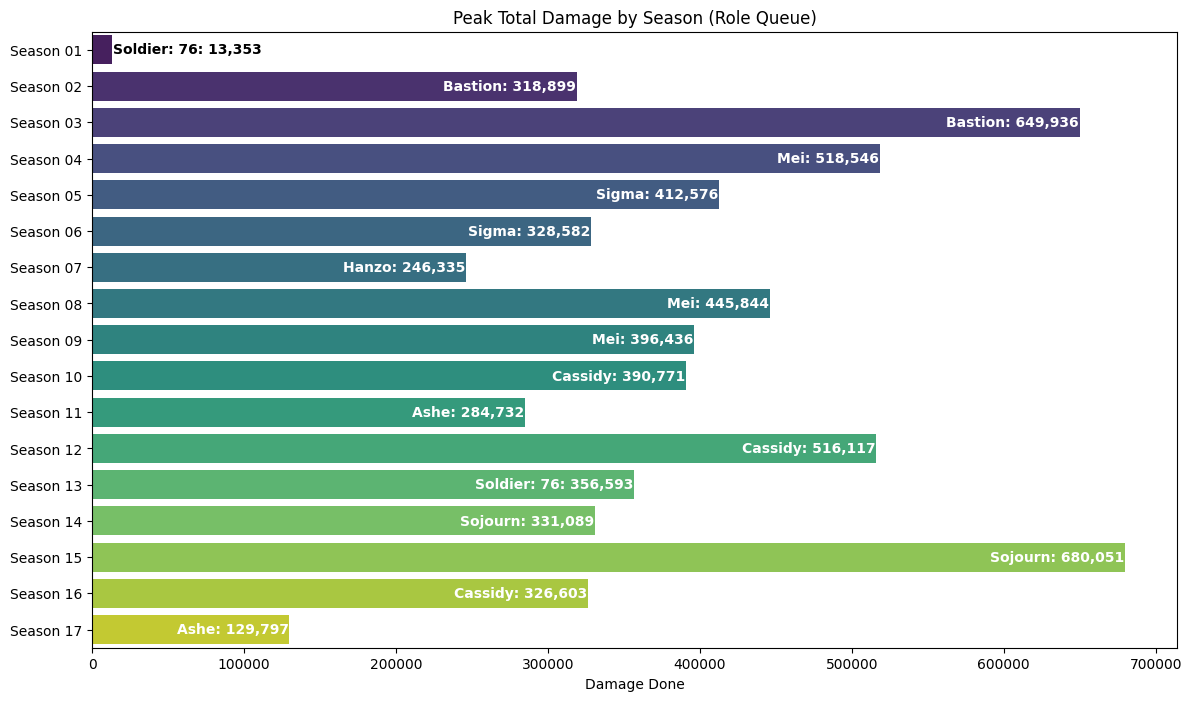

In [71]:
plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=result, 
    x="Damage Done", 
    y="Season",
    hue='Season',
    palette='viridis', 
    orient='h',
    legend=False
)

# Set a threshold under which labels go outside the bar
threshold = 100000

bars = []
for container in ax.containers:
    bars.extend(container)

# Loop over each bar and corresponding row in the dataframe
for bar, (_, row) in zip(bars, result.iterrows()):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    label = f"{row['Hero']}: {width:,.0f}"

    if width > threshold:
        ax.text(width - 500, y, label, va='center', ha='right', color='white', fontsize=10, weight='bold', antialiased=True)
    else:
        ax.text(width + 500, y, label, va='center', ha='left', color='black', fontsize=10, weight='bold', antialiased=True)


plt.title("Peak Total Damage by Season (Role Queue)")
plt.xlabel("Damage Done")
plt.ylabel("")

## Exporting to CSV - Further Visualizations in PowerBI

In [72]:
# pd.set_option('display.max_columns', None)

# hero_piv = hero.pivot_table(
#     index=['Season', 'Hero', 'Role'],   # columns to keep as rows
#     columns='Stat_Type',                # values that become new columns
#     values='Amount',                    # values to fill in those new columns
#     aggfunc='first'                     # in case of duplicates, just take the first
# ).reset_index()
# hero_piv = hero_piv.fillna(0)
# hero_piv.head()

In [73]:
# hero_piv.to_csv('hero_clean.csv', index=False)